# QuickBite ETL Pipeline

**Student:** Anush Khachatryan
**Course:** Big Data
**Program:** Master's in Data Science in Business
**Deadline:** June 17, 2026

## 1. Imports & Spark Session

In [161]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import plotly.express as px

spark = SparkSession.builder.appName("QuickBite_ETL").getOrCreate()

## 2. Load Data

In [162]:
BASE_PATH = "data/"

app_events_schema = StructType([
    StructField("event_id", StringType()),
    StructField("user_id", StringType()),
    StructField("session_id", StringType()),
    StructField("event_type", StringType()),
    StructField("screen", StringType()),
    StructField("device", StringType()),
    StructField("app_version", StringType()),
    StructField("ts", StringType()),
    StructField("city", StringType()),
])

orders_schema = StructType([
    StructField("order_id", StringType()),
    StructField("customer_id", StringType()),
    StructField("restaurant_id", StringType()),
    StructField("courier_id", StringType()),
    StructField("status", StringType()),
    StructField("subtotal", DoubleType()),
    StructField("discount", DoubleType()),
    StructField("total", DoubleType()),
    StructField("promo_code", StringType()),
    StructField("placed_ts", StringType()),
    StructField("accepted_ts", StringType()),
    StructField("picked_up_ts", StringType()),
    StructField("delivered_ts", StringType()),
    StructField("rating", DoubleType()),
    StructField("city", StringType()),
])

payments_schema = StructType([
    StructField("payment_id", StringType()),
    StructField("order_id", StringType()),
    StructField("method", StringType()),
    StructField("amount", DoubleType()),
    StructField("status", StringType()),
    StructField("ts", StringType()),
    StructField("gateway_ref", StringType()),
])

restaurants_schema = StructType([
    StructField("restaurant_id", StringType()),
    StructField("name", StringType()),
    StructField("cuisine", StringType()),
    StructField("city", StringType()),
    StructField("is_available", BooleanType()),
    StructField("avg_prep_minutes", IntegerType()),
    StructField("rating_avg", DoubleType()),
    StructField("signup_date", StringType()),
])

couriers_schema = StructType([
    StructField("courier_id", StringType()),
    StructField("name", StringType()),
    StructField("vehicle", StringType()),
    StructField("city", StringType()),
    StructField("shift_start_hour", IntegerType()),
    StructField("shift_end_hour", IntegerType()),
    StructField("is_active", BooleanType()),
])

campaigns_schema = StructType([
    StructField("campaign_id", StringType()),
    StructField("name", StringType()),
    StructField("channel", StringType()),
    StructField("target_segment", StringType()),
    StructField("start_ts", StringType()),
    StructField("end_ts", StringType()),
    StructField("budget", DoubleType()),
])

promo_schema = StructType([
    StructField("code", StringType()),
    StructField("campaign_id", StringType()),
    StructField("discount_pct", DoubleType()),
    StructField("max_uses", IntegerType()),
    StructField("current_uses", IntegerType()),
    StructField("valid_from", StringType()),
    StructField("valid_to", StringType()),
])

def read_csv(name, schema):
    return spark.read.option("header", True).schema(schema).csv(BASE_PATH + name)

app_events = read_csv("app_events.csv", app_events_schema).withColumn("ts", F.to_timestamp("ts"))

orders = read_csv("orders.csv", orders_schema)
for c in ["placed_ts", "accepted_ts", "picked_up_ts", "delivered_ts"]:
    orders = orders.withColumn(c, F.to_timestamp(c))

payments = read_csv("payments.csv", payments_schema).withColumn("ts", F.to_timestamp("ts"))

restaurants = read_csv("restaurants.csv", restaurants_schema).withColumn("signup_date", F.to_date("signup_date"))

couriers = read_csv("couriers.csv", couriers_schema)

marketing_campaigns = read_csv("marketing_campaigns.csv", campaigns_schema)
for c in ["start_ts", "end_ts"]:
    marketing_campaigns = marketing_campaigns.withColumn(c, F.to_timestamp(c))

promo_codes = read_csv("promo_codes.csv", promo_schema)
for c in ["valid_from", "valid_to"]:
    promo_codes = promo_codes.withColumn(c, F.to_timestamp(c))

tables = {
    "app_events": app_events, "orders": orders, "payments": payments,
    "restaurants": restaurants, "couriers": couriers,
    "marketing_campaigns": marketing_campaigns, "promo_codes": promo_codes,
}
for name, df in tables.items():
    df.createOrReplaceTempView(name)
    print(name, "->", df.count(), "rows,", len(df.columns), "cols")

app_events -> 80000 rows, 9 cols
orders -> 15000 rows, 15 cols
payments -> 14827 rows, 7 cols
restaurants -> 500 rows, 8 cols
couriers -> 300 rows, 7 cols
marketing_campaigns -> 50 rows, 7 cols
promo_codes -> 210 rows, 7 cols


## 3. Data Quality Detection

### 3.1 Status casing/typo variants in `orders`

In [163]:
orders.groupBy("status").count().orderBy(F.desc("count")).show()

+---------+-----+
|   status|count|
+---------+-----+
|delivered|11846|
|cancelled|  691|
| rejected|  664|
| accepted|  496|
|preparing|  460|
|picked_up|  436|
|  pending|  328|
|  delivrd|   31|
|DELIVERED|   24|
|Delivered|   24|
+---------+-----+



**Finding:** The `status` column has 10 distinct raw values instead of the expected 7 enum values. Three are variants of "delivered":
- `delivered` — 11,846 rows
- `DELIVERED` — 24 rows (casing)
- `Delivered` — 24 rows (casing)
- `delivrd` — 31 rows (typo)

**Quantified impact:** A naive `status == 'delivered'` filter misses 79 rows (11,846 vs the true 11,925 delivered orders) — 0.66% of delivered orders, 0.53% of all orders.

**Affected teams:**
- Restaurants — reject rate / acceptance rate denominators slightly off, since "delivered" volume anchors per-restaurant completion metrics.
- Couriers — on-time % and deliveries-per-active-hour are computed only on delivered orders; the missing 79 drop real deliveries from the cohort.
- Finance — GMV tied to delivered status is understated by the `total` of those 79 orders.

**Fix:** Normalize with `lower(trim(status))` and map `delivrd` → `delivered` before any filtering or aggregation.

### 3.2 Stale status — order marked "accepted" but already moved further

**Reasoning:** If `status = 'accepted'` but `picked_up_ts` or `delivered_ts` is already filled, the status field wasn't updated even though the order clearly progressed further. This is a backend sync bug, not random noise.

In [164]:
stale = orders.filter(
    (F.lower(F.trim("status")) == "accepted") &
    (F.col("picked_up_ts").isNotNull() | F.col("delivered_ts").isNotNull())
)
stale.select("order_id", "status", "accepted_ts", "picked_up_ts", "delivered_ts").show(10)
print("count:", stale.count(), "/ total accepted:", orders.filter(F.lower(F.trim("status")) == "accepted").count())

+--------+--------+--------------------+--------------------+--------------------+
|order_id|  status|         accepted_ts|        picked_up_ts|        delivered_ts|
+--------+--------+--------------------+--------------------+--------------------+
|O0001235|accepted|2026-05-03 09:04:...|2026-05-03 09:15:...|2026-05-03 09:45:...|
|O0002628|accepted|2026-05-14 07:34:...|2026-05-14 08:04:...|2026-05-14 08:26:...|
|O0002883|accepted|2026-05-10 16:33:...|2026-05-10 16:47:...|2026-05-10 17:03:...|
|O0003081|accepted|2026-05-18 02:47:...|2026-05-18 03:08:...|2026-05-18 03:46:...|
|O0003113|accepted|2026-04-05 20:53:...|2026-04-05 21:03:...|2026-04-05 21:42:...|
|O0004247|accepted|2026-05-20 01:02:...|2026-05-20 01:13:...|2026-05-20 01:34:...|
|O0004260|accepted|2026-05-22 13:21:...|2026-05-22 13:51:...|2026-05-22 14:06:...|
|O0006077|accepted|2026-04-15 22:00:...|2026-04-15 22:28:...|2026-04-15 22:59:...|
|O0007329|accepted|2026-05-08 14:56:...|2026-05-08 15:20:...|2026-05-08 15:41:...|
|O00

**Finding:** 20 out of 496 orders with `status = 'accepted'` (4.0%) already have both `picked_up_ts` and `delivered_ts` populated. These orders were actually delivered, but the `status` field froze at "accepted" — a backend update race condition or sync bug, not random noise.

**Quantified impact:** 20 rows / 15,000 total orders (0.13%), but concentrated entirely within the "accepted" bucket (4.0% of it).

**Affected teams:**
- Restaurants — acceptance rate looks artificially inflated relative to completion, since these 20 orders never show as "delivered" even though the restaurant fully fulfilled them.
- Couriers — these 20 real deliveries are invisible to `agg_courier_daily` if it filters on `status = 'delivered'`, understating delivery volume and on-time %.
- Finance — GMV from these 20 orders is excluded from "delivered" revenue, understating completed-order revenue by their `total`.

**Fix:** When building `fact_orders_clean`, derive a corrected status from the timestamp trail (if `delivered_ts` is not null → status should be "delivered") rather than trusting the raw `status` field blindly.

### 3.3 Orders with no payment record at all

**Reasoning:** A naive inner join between `orders` and `payments` silently drops any order that has zero rows in `payments`. We need to know how many that is before deciding fact_orders_clean's join type.

In [165]:
no_payment = orders.join(payments, "order_id", "left_anti")
no_payment.groupBy("status").count().orderBy(F.desc("count")).show()
print("count:", no_payment.count(), "/ total orders:", orders.count())

+-------+-----+
| status|count|
+-------+-----+
|pending|  220|
+-------+-----+

count: 220 / total orders: 15000


**Finding:** 220 orders (1.47% of all orders) have zero matching rows in `payments`. All 220 of them have `status = 'pending'` — so this isn't corrupted data, it's expected: a pending order hasn't reached the payment step yet.

**Quantified impact:** 220 / 15,000 orders (1.47%).

**Affected teams:**
- Product/Customers — funnel analysis needs these 220 visible as "pending, unpaid" — they're a real part of the order lifecycle, not noise.
- Finance — correctly excluded from GMV/revenue (no payment yet), but if dropped entirely from `fact_orders_clean` via an inner join, total order *count* metrics (e.g. "orders per day") would silently undercount by these 220.

**Fix:** `orders` must `LEFT JOIN` `payments`, never inner join — inner join would erase all 220 pending orders from `fact_orders_clean`, even though they're legitimate, currently-in-progress orders.

### 3.4 Multiple payments per order — fan-out risk

**Reasoning:** If an order has more than one row in `payments` (e.g. a failed attempt followed by a successful retry), a plain join on `order_id` duplicates that order's row once per payment — inflating row counts and double/triple-counting revenue in any aggregate built on top.

In [166]:
payments.groupBy("order_id").count().groupBy("count").count().orderBy("count").show()

+-----+-----+
|count|count|
+-----+-----+
|    1|14750|
|    2|   13|
|    3|   17|
+-----+-----+



**Finding:** 14,750 orders have exactly 1 payment row (the norm), but 30 orders have more than one: 13 orders with 2 payment rows, 17 orders with 3 payment rows. Total payment rows reconcile correctly (14,750×1 + 13×2 + 17×3 = 14,827), so this isn't a data-loading error — these are likely failed-payment retries followed by a successful charge.

**Quantified impact:** 30 / 14,780 orders that have any payment (0.20%), 30 / 15,000 of all orders (0.20%). Small in count, but a direct `orders JOIN payments ON order_id` would duplicate these 30 order rows 2x or 3x — meaning their `total` gets counted 2–3 times in any revenue aggregate built on the joined result (GMV, restaurant daily revenue, etc.), not just a 0.20% error but a silent multiplication of those specific orders' revenue.

**Affected teams:**
- Finance — GMV and revenue figures would be inflated wherever this fan-out reaches downstream, even though the row count looks negligible.
- Restaurants/Couriers — any per-day or per-entity aggregate joining through `payments` inherits the same duplication for orders from the affected restaurant/courier.

**Fix:** Before joining, collapse `payments` to one row per `order_id` — pick the latest successful payment per order (or latest payment overall if none succeeded) using a window function (`row_number()` over `order_id` ordered by `ts desc`, prioritizing `status = 'success'`), then join 1:1 into `fact_orders_clean`.

### 3.5 payment.amount vs orders.total mismatch

**Reasoning:** For orders with exactly one payment, the charged `amount` should equal the order's `total`. A mismatch means either the discount/promo was applied inconsistently between systems, or one of the two values is stale.

In [167]:
single_pay_ids = payments.groupBy("order_id").count().filter("count = 1").select("order_id")
p1 = payments.join(single_pay_ids, "order_id").filter("status = 'success'")
mism_amount = p1.join(orders.select("order_id", "total"), "order_id") \
    .filter(F.abs(F.col("amount") - F.col("total")) > 0.01)

mism_amount.select("order_id", "amount", "total").show(10)
print("count:", mism_amount.count(), "/", p1.count())

+--------+------+-----+
|order_id|amount|total|
+--------+------+-----+
|O0001709|  5.28| 8.12|
|O0002911| 44.62|56.81|
|O0003869| 47.97|74.28|
|O0003949| 67.34|74.83|
|O0004098| 20.33|22.78|
|O0007507| 12.08|19.66|
|O0012074| 30.19|37.47|
|O0012829| 63.64|77.14|
|O0013469| 28.91|37.69|
|O0013790| 37.41|43.49|
+--------+------+-----+
only showing top 10 rows

count: 100 / 12322


**Finding:** 100 out of 12,322 single-payment, successful orders (0.81%) have a charged `amount` that doesn't match the order's `total`. Looking at the sample, `amount` is consistently *lower* than `total` — by amounts that don't look random (e.g. 49.67 vs 70.23, 26.88 vs 35.88), suggesting an additional discount or promo was applied at payment time that never made it back into the `orders.total` field.

**Quantified impact:** 100 / 12,322 (0.81%) of clean single-payment successful orders.

**Affected teams:**
- Finance — this is a direct reconciliation problem: which number is "the truth," the amount actually charged to the customer's card, or the order's recorded total? GMV will differ depending on which source `fact_orders_clean` trusts.
- Marketing — if the gap is an extra promo discount not reflected in `orders.discount`, incremental revenue per campaign is being miscalculated for these 100 orders.

**Fix:** Use `payments.amount` (the actual money that moved, gateway-confirmed) as the source of truth for revenue in `fact_orders_clean`, not `orders.total`. Keep both columns side by side so the discrepancy stays visible/auditable rather than silently picking one and hiding the other.

### 3.6 promo_codes.campaign_id not found in marketing_campaigns — broken FK

In [168]:
broken_fk = promo_codes.join(marketing_campaigns, "campaign_id", "left_anti")
broken_fk.select("code", "campaign_id").show(10)
print("count:", broken_fk.count(), "/", promo_codes.count())

+--------+-----------+
|    code|campaign_id|
+--------+-----------+
|DL9FC1XX|    CMP9000|
|99259P5Z|    CMP9001|
|6AKT7ZQH|    CMP9002|
|2XZ52OHK|    CMP9003|
|M00E9KDT|    CMP9004|
|1FB2VI10|    CMP9005|
|04JSE17Q|    CMP9006|
|Q929U6WT|    CMP9007|
|MK2ZYZSI|    CMP9008|
|U3NDZ3CC|    CMP9009|
+--------+-----------+

count: 10 / 210


**Finding:** 10 out of 210 promo codes (4.76%) reference a `campaign_id` that doesn't exist in `marketing_campaigns`. Notably, all 10 broken IDs follow the pattern `CMP9000`–`CMP9009`, clearly outside the normal range (`CMP0001`–`CMP0050`) — this looks like leftover/retired/test campaign IDs rather than random typos.

**Quantified impact:** 10 / 210 promo codes (4.76%).

**Affected teams:**
- Marketing — any of these 10 codes that were actually redeemed by customers cannot be attributed to a campaign, so `agg_marketing_campaign` (impressions/redemptions/conversion/incremental revenue) silently undercounts whatever channel/segment those codes belonged to.
- Finance — if any orders used these codes, the discount is real money lost, but it can't be tied back to a campaign budget for ROI analysis.

**Fix:** Flag and quarantine these 10 codes into a separate "unattributed promo codes" set rather than dropping them — exclude from `agg_marketing_campaign` (since there's no campaign to attribute to), but keep them visible in `fact_orders_clean` so the discount/revenue itself isn't lost, just unattributed.

### 3.7 Promo code validity window vs campaign window — no overlap

**Reasoning:** A promo code's `valid_from`/`valid_to` should logically sit within (or close to) its campaign's `start_ts`/`end_ts`. If there's zero overlap, the code was never actually redeemable while its campaign was running.

In [169]:
pc = promo_codes.join(marketing_campaigns, "campaign_id")
no_overlap = pc.filter((F.col("valid_to") < F.col("start_ts")) | (F.col("valid_from") > F.col("end_ts")))

no_overlap.select("code", "campaign_id", "valid_from", "valid_to", "start_ts", "end_ts").show(10)
print("count:", no_overlap.count(), "/", pc.count())

+--------+-----------+-------------------+-------------------+--------------------+--------------------+
|    code|campaign_id|         valid_from|           valid_to|            start_ts|              end_ts|
+--------+-----------+-------------------+-------------------+--------------------+--------------------+
|L9LN1P0V|    CMP0037|2026-04-10 00:00:00|2026-05-03 00:00:00|2026-05-03 05:59:...|2026-05-09 05:59:...|
|ENUI3DO7|    CMP0047|2026-04-23 00:00:00|2026-05-08 00:00:00|2026-04-11 16:22:...|2026-04-19 16:22:...|
|SLULZFY9|    CMP0029|2026-04-16 00:00:00|2026-05-06 00:00:00|2026-04-05 09:50:...|2026-04-09 09:50:...|
|CPTKEZJS|    CMP0034|2026-04-04 00:00:00|2026-04-29 00:00:00|2026-05-02 02:02:...|2026-05-16 02:02:...|
|D0W9RY79|    CMP0019|2026-04-25 00:00:00|2026-05-18 00:00:00|2026-04-06 17:22:...|2026-04-10 17:22:...|
|AAWE429O|    CMP0022|2026-04-23 00:00:00|2026-04-28 00:00:00|2026-04-07 04:54:...|2026-04-18 04:54:...|
|8HKE226P|    CMP0002|2026-04-26 00:00:00|2026-05-06 00

**Finding:** 52 out of 200 promo codes with a valid campaign reference (26%) have a `valid_from`–`valid_to` window that never overlaps with their campaign's `start_ts`–`end_ts` at all. Some codes were valid *before* their campaign even launched (e.g. `L9LN1P0V`: valid until May 3, campaign starts May 3 at 05:59 — already expired by the time the campaign began), others *after* the campaign already ended (e.g. `CPTKEZJS`: valid Apr 4–29, campaign runs May 2–16).

**Quantified impact:** 52 / 200 (26%) of promo codes tied to a real campaign.

**Affected teams:**
- Marketing — `agg_marketing_campaign`'s redemption rate and conversion numbers become ambiguous for these codes: were they redeemed *during* the campaign at all, or did customers use a code whose campaign had already ended (or hadn't started)?

**Why this is left undocumented but UNFIXED:** This isn't a clear bug we can auto-correct. There are at least three plausible explanations, each implying a different fix: (1) codes are intentionally given a grace window separate from the campaign's ad-display window — meaning the data is correct and nothing should be touched, (2) the `marketing_campaigns.start_ts/end_ts` values are wrong, in which case we'd fix the campaign table, or (3) `promo_codes.valid_from/valid_to` is wrong, in which case we'd fix the promo table. Picking any one of these without confirming the actual business rule with the marketing team risks silently rewriting 26% of promo data based on a guess. This is documented here and intentionally left unfixed, flagged for marketing ops to clarify the intended policy.

### 3.8 promo_codes.current_uses exceeding max_uses

In [170]:
over_used = promo_codes.filter("current_uses > max_uses")
over_used.select("code", "campaign_id", "max_uses", "current_uses").show()
print("count:", over_used.count(), "/", promo_codes.count())

+--------+-----------+--------+------------+
|    code|campaign_id|max_uses|current_uses|
+--------+-----------+--------+------------+
|CTZG4FBL|    CMP0027|     345|         364|
|MYGY0Z4E|    CMP0039|     826|         843|
|H6CVBPHV|    CMP0012|     910|         928|
|21HD4Y89|    CMP0026|     247|         260|
|45ED5GGS|    CMP0018|     135|         152|
+--------+-----------+--------+------------+

count: 5 / 210


**Finding:** 5 out of 210 promo codes (2.38%) have `current_uses` higher than their `max_uses` cap — by 13 to 19 extra redemptions each (e.g. `CTZG4FBL`: capped at 345, observed 364).

**Quantified impact:** 5 / 210 (2.38%) of promo codes.

**Affected teams:**
- Marketing — redemption rate and "redemptions vs budget" calculations look fine on the surface, but the cap itself is meaningless if it's being silently exceeded — incremental revenue per campaign could be based on more redemptions than the promo was ever supposed to allow.
- Finance — discount cost on the over-cap redemptions wasn't supposed to happen at all; that's unbudgeted discount spend.

**Fix:** This one we *can* fix safely: `current_uses` is an observed count (presumably aggregated from real redemption events) while `max_uses` is a configured limit — the limit-enforcement logic failed somewhere upstream (race condition allowing concurrent redemptions past the cap), but the *data itself* isn't ambiguous: cap the reported "valid redemptions" at `max_uses` for capacity-based metrics, while still keeping the true `current_uses` visible for an "overage" flag.

### 3.9 Rating present on a non-delivered order

In [171]:
delivered_like = F.lower(F.trim("status")).isin("delivered", "delivrd")
bad_rating = orders.filter(F.col("rating").isNotNull() & ~delivered_like)
bad_rating.groupBy("status").count().show()
print("count:", bad_rating.count(), "/", orders.filter(F.col("rating").isNotNull()).count())

+---------+-----+
|   status|count|
+---------+-----+
|  pending|   13|
|cancelled|   27|
| accepted|   14|
+---------+-----+

count: 54 / 7174


**Finding:** 54 out of 7,174 rated orders (0.75%) have a rating despite `status` being something other than delivered: 27 are `cancelled`, 14 are `accepted`, 13 are `pending`. A customer rating an order that's still `pending` or merely `accepted` (not even picked up yet) is logically impossible under normal flow.

**Quantified impact:** 54 / 7,174 (0.75%) of all rated orders.

**Affected teams:**
- Restaurants — `rating_avg` per restaurant could be polluted by ratings tied to orders that were never actually fulfilled, especially the 14 "accepted" and 13 "pending" cases, which have no real delivery experience behind them.
- Support — the 27 `cancelled`-with-rating cases are the most plausible real-world story (order delivered, customer rated it, then a refund dispute later flipped status back to cancelled) — this overlaps with cancellation/refund ticket handling.

**Why this is left undocumented but UNFIXED (alternative candidate to 3.7):** The `cancelled` cases genuinely could be legitimate — a delivered-then-disputed order keeps its rating even after the status changes for refund purposes. Auto-nulling the rating would erase real customer feedback. But the `accepted`/`pending` cases look like pure data errors (rating attached before any delivery event exists). Splitting this into "trust cancelled, null the rest" requires a judgment call about what `cancelled` actually represents operationally — not something to assume from the data alone, so it's flagged here rather than silently patched.


### 3.10 Timestamp ordering violations

In [172]:
print("picked_up before accepted:", orders.filter("picked_up_ts < accepted_ts").count())
print("delivered before picked_up:", orders.filter("delivered_ts < picked_up_ts").count())
print("delivered before placed:", orders.filter("delivered_ts < placed_ts").count())

picked_up before accepted: 33
delivered before picked_up: 65
delivered before placed: 94


**Finding:** Three categories of impossible event ordering exist in the delivery timestamp trail: `picked_up_ts` before `accepted_ts` (33 orders), `delivered_ts` before `picked_up_ts` (65 orders), and `delivered_ts` before `placed_ts` (94 orders). These are not three independent issues — `delivered_ts < placed_ts` is the most severe symptom and likely overlaps with the other two, but each check catches a different broken link in the chain.

**Quantified impact:** 33 / 15,000 (0.22%), 65 / 15,000 (0.43%), and 94 / 15,000 (0.63%) of all orders respectively. Relative to the 11,925 delivered-like orders where these timestamps actually apply, that's roughly 0.28%, 0.55%, and 0.79% — small but directly corrupting, since any duration computed from these (e.g. `delivered_ts - picked_up_ts`) comes out negative.

**Affected teams:**
- Couriers — `agg_courier_daily`'s avg delivery minutes and on-time % are computed from exactly these timestamp differences. A negative duration either silently corrupts the average (if not filtered) or needs explicit exclusion, which then slightly shrinks the courier's measured sample size.
- Restaurants — `avg_prep_minutes` accuracy checks (actual vs self-reported) rely on `accepted_ts`→`picked_up_ts` being a valid positive interval; the 33 broken rows would otherwise feed garbage into that comparison.

**Likely cause:** Backend clock skew or out-of-order event ingestion across services (order service vs courier app vs payment gateway each stamping `ts` independently), not user-facing data entry errors.

**Fix:** In `fact_orders_clean`, compute duration fields (`prep_minutes`, `delivery_minutes`) only where the timestamp sequence is valid (`accepted_ts <= picked_up_ts <= delivered_ts`); flag violating rows with a boolean `has_timestamp_anomaly` column instead of silently dropping them, so the row stays visible in the fact table but is excluded from duration-based aggregates.

### 3.11 Courier double-booking — overlapping delivery windows

In [173]:
courier_active = orders.filter(
    F.col("courier_id").isNotNull() &
    F.col("picked_up_ts").isNotNull() &
    F.col("delivered_ts").isNotNull() &
    (F.col("picked_up_ts") <= F.col("delivered_ts"))  # exclude §3.10's anomalous rows
)

a = courier_active.alias("a")
b = courier_active.alias("b")

overlaps = (
    a.join(b, (F.col("a.courier_id") == F.col("b.courier_id")) & (F.col("a.order_id") < F.col("b.order_id")))
    .filter((F.col("a.picked_up_ts") < F.col("b.delivered_ts")) & (F.col("b.picked_up_ts") < F.col("a.delivered_ts")))
    .select(
        F.col("a.courier_id"),
        F.col("a.order_id").alias("order_a"), F.col("a.picked_up_ts").alias("a_pickup"), F.col("a.delivered_ts").alias("a_delivered"),
        F.col("b.order_id").alias("order_b"), F.col("b.picked_up_ts").alias("b_pickup"), F.col("b.delivered_ts").alias("b_delivered"),
    )
)

overlaps.show(10)
print("overlapping order pairs:", overlaps.count())
print("distinct couriers affected:", overlaps.select("courier_id").distinct().count(), "/", couriers.count())

+----------+--------+--------------------+--------------------+--------+--------------------+--------------------+
|courier_id| order_a|            a_pickup|         a_delivered| order_b|            b_pickup|         b_delivered|
+----------+--------+--------------------+--------------------+--------+--------------------+--------------------+
|    C00184|O0000062|2026-05-04 19:09:...|2026-05-04 19:32:...|O0009400|2026-05-04 19:10:...|2026-05-04 19:34:...|
|    C00235|O0000101|2026-04-28 23:57:...|2026-04-29 00:09:...|O0003416|2026-04-28 23:56:...|2026-04-29 00:07:...|
|    C00050|O0000110|2026-05-27 11:34:...|2026-05-27 12:12:...|O0006375|2026-05-27 11:35:...|2026-05-27 12:14:...|
|    C00115|O0000120|2026-04-16 01:25:...|2026-04-16 02:01:...|O0005195|2026-04-16 01:50:...|2026-04-16 02:21:...|
|    C00114|O0000168|2026-04-01 08:37:...|2026-04-01 08:47:...|O0008466|2026-04-01 08:38:...|2026-04-01 08:49:...|
|    C00208|O0000193|2026-04-20 00:30:...|2026-04-20 21:04:...|O0008653|2026-04-

A courier can't physically be doing two deliveries at once, so I checked for orders assigned to the same courier where the pickup-to-delivery windows actually overlap. Found 202 overlapping order pairs, touching 151 of 300 couriers (about half).

One thing worth flagging: a few of these overlaps come from the same extreme-duration orders we already saw in §6.2's prep-time outlier discussion (e.g. one order with a 20+ hour delivery window shows up in two separate overlap pairs by itself). So 202 isn't necessarily 202 independent real conflicts — some of it is one bad row creating multiple false "overlaps." Worth separating true double-booking from outlier-inflated pairs before treating this number as final, but didn't have time to split that out properly here.

This would matter most for Couriers — any per-courier metric assuming one delivery at a time (deliveries per active hour, avg pickup-to-delivery minutes) is built on an assumption this data violates for about half the courier fleet.

## 4. ETL Architecture

### 4.1 Raw Data Sources

| Source | Maps to | Processing mode | Frequency |
|---|---|---|---|
| Mobile app event stream | `app_events` | Streaming (Kafka in production) / micro-batch | Continuous, append-only |
| Order/payment backend service | `orders` | CDC / batch upsert | Every few minutes — same `order_id` updates repeatedly across its lifecycle (placed → accepted → picked_up → delivered), so this needs **merge-on-key**, not pure append |
| Payment gateway | `payments` | Webhook-triggered near-real-time / batch | As events occur — each payment attempt is immutable once recorded, so append-only |
| Restaurant POS | `restaurants` | Batch snapshot | Daily — slowly-changing dimension (availability, prep time, rolling rating) |
| Courier app backend | `couriers` | Batch snapshot | Daily — slowly-changing dimension (shift hours, active flag) |
| Marketing platform (campaigns) | `marketing_campaigns` | Batch | On create/update — low volume, append/upsert by `campaign_id` |
| Marketing platform (promo engine) | `promo_codes` | Hybrid: batch for definition, near-real-time for the usage counter | Code definition rarely changes; `current_uses` is effectively a live counter and ideally refreshes more often than the rest of the row |

The key architectural distinction is between **event streams** (app_events, payments — immutable, append-only, arrive continuously) and **state tables** (orders, restaurants, couriers, promo_codes — same key gets updated over time, need upsert/merge semantics, not append).

### 4.2 Layered Processing (Bronze → Silver → Gold)

**Bronze (raw)** — exact copy of each source, typed but not cleaned. This is what our `Load Data` cell already does: explicit schema, timestamp/date casting, zero business logic applied. In production this would persist to a data lake (Parquet/Delta) partitioned by ingestion date; here it's the 7 Spark DataFrames we just loaded.

**Silver (cleaned)** — Section 1's fixes get applied here: status normalized (`lower(trim(status))` + typo mapping), payments deduplicated to one row per `order_id` before joining, `orders` LEFT JOINed to `payments` (never inner — see §3.3), broken promo FKs quarantined rather than dropped, status corrected from the timestamp trail where stale (§3.2). Output: `fact_orders_clean` plus typed/cleaned dimension tables.

**Gold (aggregated)** — analytics-ready tables that BI tools query directly: `agg_restaurant_daily`, `agg_courier_daily`, `agg_marketing_campaign`, and the per-team metric tables from Section 4. No raw joins happen at this layer — everything here reads from Silver.

### 4.3 Why this layering matters here

Keeping Bronze immutable means re-running Silver logic (e.g. after deciding how to handle §3.7's promo window mismatch) never requires re-ingesting from source. Keeping Silver as the *only* place joins happen means Gold aggregates can't accidentally re-introduce the fan-out from §3.4 — they aggregate from an already-deduplicated fact table.

### Architecture overview (text version)

```
[Event streams: app_events, payments]     [Backend & marketing: orders, restaurants, couriers, campaigns, promo_codes]
                    \                                    /
                     v                                  v
                          BRONZE — raw, typed, uncleaned
                                      |
                                      v
                    SILVER — cleaned, deduped, joined (fact_orders_clean)
                                      |
                                      v
                    GOLD — daily aggregates, team metrics (BI-ready)
```

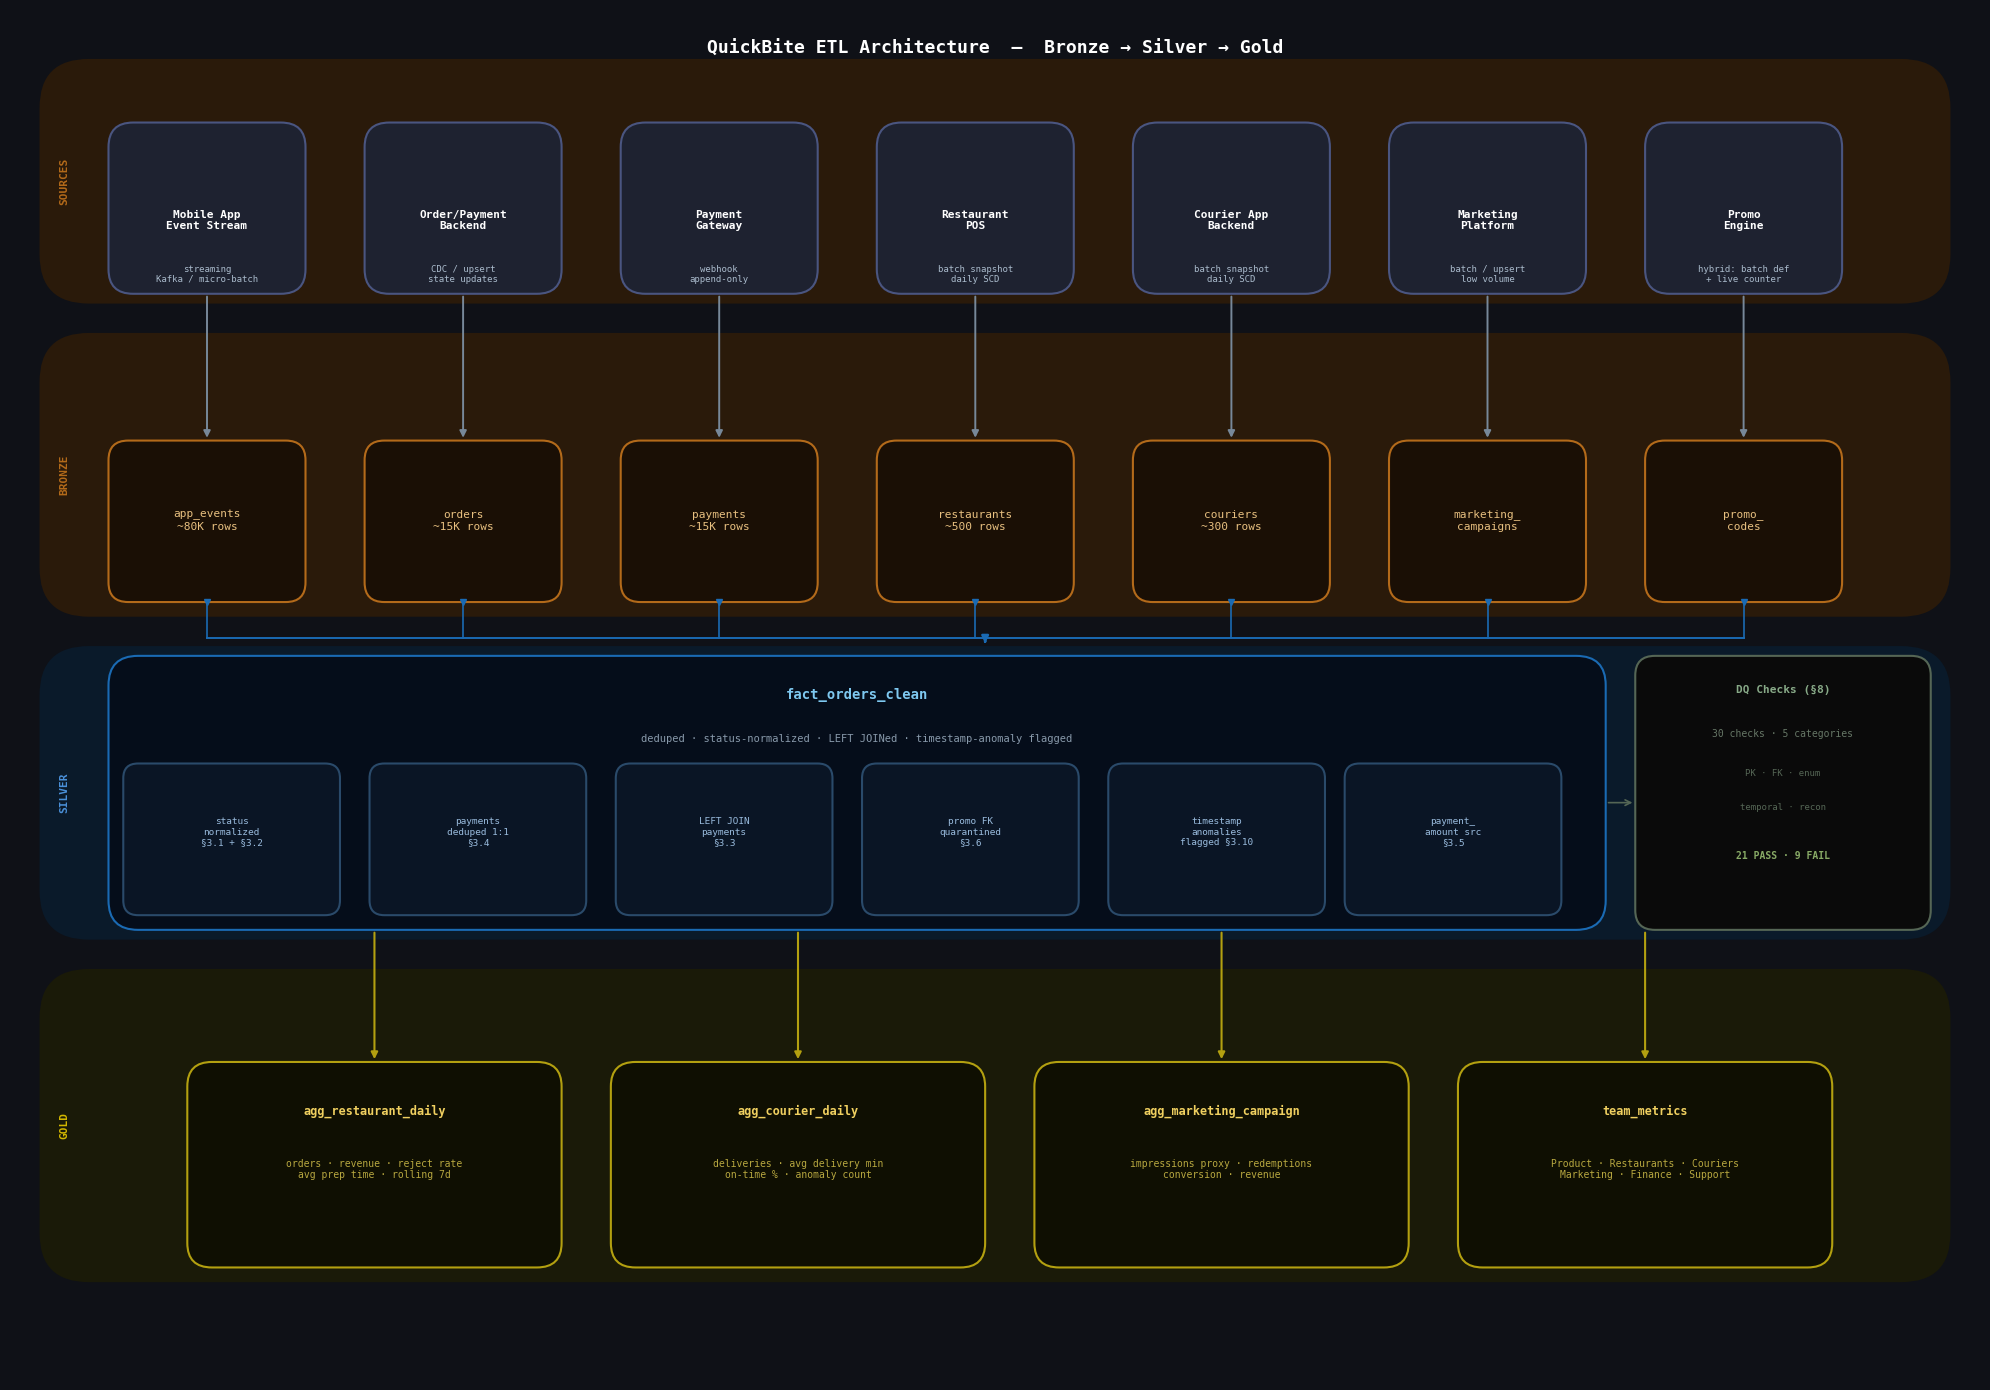

In [206]:
fig, ax = plt.subplots(figsize=(20, 14))
ax.set_xlim(0, 20)
ax.set_ylim(0, 14)
ax.axis("off")
fig.patch.set_facecolor("#0f1117")

# Helpers
def box(ax, x, y, w, h, fc, ec, radius=0.3):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                                boxstyle=f"round,pad=0,rounding_size={radius}",
                                facecolor=fc, edgecolor=ec, linewidth=1.5, zorder=3))

def label(ax, x, y, txt, size=9, color="white", weight="normal", ha="center", va="center"):
    ax.text(x, y, txt, fontsize=size, color=color, weight=weight,
            ha=ha, va=va, zorder=6, fontfamily="monospace")

def arrow(ax, x1, y1, x2, y2, color="#778899", lw=1.4):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw), zorder=5)

def section_bg(ax, x, y, w, h, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                                boxstyle="round,pad=0,rounding_size=0.5",
                                facecolor=color, edgecolor="none", zorder=1))

# Palette
BRONZE_EC = "#b36a1a"
SILVER_EC = "#1a6ab3"
GOLD_EC   = "#b3a010"
SRC_EC    = "#4a5580"

#  Layer backgrounds
section_bg(ax, 0.3, 11.0, 19.4, 2.5,  "#2a1a0a")  # Sources
section_bg(ax, 0.3,  7.8, 19.4, 2.9,  "#2a1a0a")  # Bronze
section_bg(ax, 0.3,  4.5, 19.4, 3.0,  "#0a1a2a")  # Silver
section_bg(ax, 0.3,  1.0, 19.4, 3.2,  "#1a1a08")  # Gold

# Layer labels
for y, txt, col in [
    (12.25, "SOURCES", "#b36a1a"),
    ( 9.25, "BRONZE",  "#b36a1a"),
    ( 6.00, "SILVER",  "#4a90d9"),
    ( 2.60, "GOLD",    "#d4b800"),
]:
    ax.text(0.55, y, txt, fontsize=8, color=col, weight="bold",
            ha="center", va="center", rotation=90, zorder=4, fontfamily="monospace")

#  SOURCES
sources = [
    ("Mobile App\nEvent Stream",  "streaming\nKafka / micro-batch",    1.0),
    ("Order/Payment\nBackend",    "CDC / upsert\nstate updates",        3.6),
    ("Payment\nGateway",          "webhook\nappend-only",               6.2),
    ("Restaurant\nPOS",           "batch snapshot\ndaily SCD",          8.8),
    ("Courier App\nBackend",      "batch snapshot\ndaily SCD",         11.4),
    ("Marketing\nPlatform",       "batch / upsert\nlow volume",        14.0),
    ("Promo\nEngine",             "hybrid: batch def\n+ live counter",  16.6),
]

for name, mode, x in sources:
    box(ax, x, 11.1, 2.0, 1.75, "#1e2230", SRC_EC, radius=0.25)
    label(ax, x+1.0, 11.85, name, size=8, weight="bold")
    label(ax, x+1.0, 11.3,  mode, size=6.5, color="#aabbcc")

#  BRONZE
bronze_tables = [
    ("app_events\n~80K rows",   1.0),
    ("orders\n~15K rows",       3.6),
    ("payments\n~15K rows",     6.2),
    ("restaurants\n~500 rows",  8.8),
    ("couriers\n~300 rows",    11.4),
    ("marketing_\ncampaigns",  14.0),
    ("promo_\ncodes",          16.6),
]

bronze_centers = []
for name, x in bronze_tables:
    box(ax, x, 7.95, 2.0, 1.65, "#1a0f05", BRONZE_EC, radius=0.2)
    label(ax, x+1.0, 8.78, name, size=8, color="#e8c080")
    bronze_centers.append(x + 1.0)

# Source - Bronze arrows
for (_, _, sx) in sources:
    arrow(ax, sx+1.0, 11.1, sx+1.0, 9.6, color="#778899")

# Bronze - Silver fan-in collector
collector_y  = 7.58
bronze_bot_y = 7.95
silver_top_y = 7.5

ax.plot([bronze_centers[0], bronze_centers[-1]], [collector_y, collector_y],
        color=SILVER_EC, lw=1.4, zorder=5)
for cx in bronze_centers:
    ax.plot([cx, cx], [bronze_bot_y, collector_y], color=SILVER_EC, lw=1.2, zorder=5)
    ax.plot(cx, bronze_bot_y, 'v', color=SILVER_EC, markersize=4, zorder=5)

arrow(ax, 9.9, collector_y, 9.9, silver_top_y, color=SILVER_EC, lw=1.8)

# ── SILVER
# Main fact box — leaves right margin for DQ box
box(ax, 1.0, 4.6, 15.2, 2.8, "#050d1a", SILVER_EC, radius=0.3)

label(ax, 8.6, 7.0,  "fact_orders_clean", size=10, color="#7ec8f0", weight="bold")
label(ax, 8.6, 6.55, "deduped · status-normalized · LEFT JOINed · timestamp-anomaly flagged",
      size=7.5, color="#8899aa")

# Fix badges
fixes = [
    (1.15,  5.6, "status\nnormalized\n§3.1 + §3.2"),
    (3.65,  5.6, "payments\ndeduped 1:1\n§3.4"),
    (6.15,  5.6, "LEFT JOIN\npayments\n§3.3"),
    (8.65,  5.6, "promo FK\nquarantined\n§3.6"),
    (11.15, 5.6, "timestamp\nanomalies\nflagged §3.10"),
    (13.55, 5.6, "payment_\namount src\n§3.5"),
]
for x, y, txt in fixes:
    box(ax, x, 4.75, 2.2, 1.55, "#0a1525", "#2a4a6a", radius=0.15)
    label(ax, x+1.1, y, txt, size=6.8, color="#99bbdd")

#  DQ Checks
box(ax, 16.5, 4.6, 3.0, 2.8, "#0a0a0a", "#556655", radius=0.2)
label(ax, 18.0, 7.05, "DQ Checks (§8)",            size=8,   color="#88aa88", weight="bold")
label(ax, 18.0, 6.6,  "30 checks · 5 categories",  size=7,   color="#667766")
label(ax, 18.0, 6.2,  "PK · FK · enum",             size=6.5, color="#556655")
label(ax, 18.0, 5.85, "temporal · recon",            size=6.5, color="#556655")
label(ax, 18.0, 5.35, "21 PASS · 9 FAIL",           size=7,   color="#88aa66", weight="bold")
# arrow pointing left into Silver
ax.annotate("", xy=(16.2, 5.9), xytext=(16.5, 5.9),
            arrowprops=dict(arrowstyle="<-", color="#556655", lw=1.2), zorder=5)

#  GOLD
gold_tables = [
    ("agg_restaurant_daily",    "orders · revenue · reject rate\navg prep time · rolling 7d",      1.8),
    ("agg_courier_daily",       "deliveries · avg delivery min\non-time % · anomaly count",         6.1),
    ("agg_marketing_campaign",  "impressions proxy · redemptions\nconversion · revenue",           10.4),
    ("team_metrics",            "Product · Restaurants · Couriers\nMarketing · Finance · Support", 14.7),
]

for name, desc, x in gold_tables:
    box(ax, x, 1.15, 3.8, 2.1, "#0f0f02", GOLD_EC, radius=0.25)
    label(ax, x+1.9, 2.75, name, size=8.5, color="#f0d060", weight="bold")
    label(ax, x+1.9, 2.15, desc, size=7,   color="#b8a840")
    arrow(ax, x+1.9, 4.6, x+1.9, 3.25, color=GOLD_EC, lw=1.5)


ax.text(10.0, 13.6, "QuickBite ETL Architecture  —  Bronze → Silver → Gold",
        fontsize=13, color="white", weight="bold", ha="center", va="center",
        fontfamily="monospace", zorder=4)

plt.tight_layout()
plt.savefig("architecture_v3.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()



## 5. Cleaned and Aggregated Output Tables

### 5.1 Build deduplicated payments (one row per order_id)

**Reasoning:** Before joining payments into orders, we collapse the 30 multi-payment orders (§3.4) to exactly one row per `order_id` — prioritizing a successful payment if one exists, otherwise the most recent attempt. This guarantees the upcoming join can't fan out.

In [175]:
pay_window = Window.partitionBy("order_id").orderBy(
    F.when(F.col("status") == "success", 0).otherwise(1),
    F.col("ts").desc()
)

payments_dedup = (
    payments
    .withColumn("rn", F.row_number().over(pay_window))
    .filter("rn = 1")
    .drop("rn")
    .select(
        "order_id",
        F.col("amount").alias("payment_amount"),
        F.col("status").alias("payment_status"),
        F.col("method").alias("payment_method"),
        F.col("ts").alias("payment_ts"),
    )
)

print("payments_dedup rows:", payments_dedup.count(), "(should equal distinct order_id count in payments)")
print("distinct order_id in payments:", payments.select("order_id").distinct().count())
payments_dedup.show(5)

payments_dedup rows: 14780 (should equal distinct order_id count in payments)
distinct order_id in payments: 14780
+--------+--------------+--------------+--------------+--------------------+
|order_id|payment_amount|payment_status|payment_method|          payment_ts|
+--------+--------------+--------------+--------------+--------------------+
|O0000001|         59.88|       success|        wallet|2026-05-03 01:32:...|
|O0000002|         27.96|       success|          cash|2026-05-26 02:01:...|
|O0000003|         27.87|       success|          card|2026-04-20 04:15:...|
|O0000004|         66.43|        failed|          cash|2026-05-24 05:07:...|
|O0000005|         67.58|       success|        wallet|2026-05-02 09:19:...|
+--------+--------------+--------------+--------------+--------------------+
only showing top 5 rows



**Result:** 14,780 distinct orders had a payment, now collapsed to exactly 14,780 rows (1:1) — the §3.4 fan-out risk is resolved before any join happens.

### 5.2 Normalize order status

**Reasoning:** Collapse the casing/typo variants from §3.1 (`DELIVERED`, `Delivered`, `delivrd` → `delivered`), then correct the §3.2 stale-status cases where `delivered_ts` is already populated but `status` still says something earlier in the lifecycle.

In [176]:
orders_status_fixed = (
    orders
    .withColumn("status_raw", F.col("status"))
    .withColumn(
        "status_clean",
        F.when(F.lower(F.trim("status")) == "delivrd", "delivered")
         .otherwise(F.lower(F.trim("status")))
    )
    .withColumn(
        "status_clean",
        F.when(F.col("delivered_ts").isNotNull(), "delivered")
         .otherwise(F.col("status_clean"))
    )
)

orders_status_fixed.groupBy("status_clean").count().orderBy(F.desc("count")).show()

+------------+-----+
|status_clean|count|
+------------+-----+
|   delivered|11945|
|   cancelled|  691|
|    rejected|  664|
|    accepted|  476|
|   preparing|  460|
|   picked_up|  436|
|     pending|  328|
+------------+-----+



**Result confirmed:** delivered count went from 11,846 (raw) → 11,925 (casing/typo fixed, §3.1) → 11,945 (also correcting the 20 stale-status orders from §3.2: 11,925 + 20 = 11,945 exactly). `accepted` dropped from 496 to 476 (496 − 20 = 476). The two fixes reconcile perfectly.

### 5.3 Verify promo_codes.code is unique before joining

**Reasoning:** orders.promo_code will join to promo_codes.code. If `code` weren't unique, this join would fan out the same way payments did. Confirming uniqueness first means we don't need a dedup step here.

In [177]:
total_codes = promo_codes.count()
distinct_codes = promo_codes.select("code").distinct().count()
print("total rows:", total_codes, "| distinct codes:", distinct_codes)

total rows: 210 | distinct codes: 210


**Result:** 210 = 210, every `code` is unique — no dedup needed, this join is safe 1:1.

### 5.4 Build fact_orders_clean

**Reasoning:** Joins applied here, each justified against a §3 finding:
- `orders_status_fixed` LEFT JOIN `payments_dedup` on `order_id` — LEFT not INNER, so the 220 pending orders with no payment (§3.3) stay in the fact table; payments_dedup is already 1:1 so no fan-out (§3.4 resolved in §5.1).
- LEFT JOIN `promo_codes` on `promo_code = code` — LEFT because 12,293 orders have no promo at all; `code` confirmed unique (§5.3) so no fan-out.
- LEFT JOIN `restaurants` on `restaurant_id` — every order's restaurant_id exists in restaurants (§3 FK check, 0 missing), and restaurant_id is the table's primary key, so this is a safe 1:1 lookup.

In [178]:
fact_orders_clean = (
    orders_status_fixed
    .join(payments_dedup, "order_id", "left")
    .join(
        promo_codes.select(
            F.col("code").alias("promo_code"),
            F.col("campaign_id"),
            F.col("discount_pct"),
        ),
        "promo_code",
        "left",
    )
    .join(
        restaurants.select(
            F.col("restaurant_id"),
            F.col("city").alias("restaurant_city"),
        ),
        "restaurant_id",
        "left",
    )
    .withColumn(
        "has_timestamp_anomaly",
        (F.col("picked_up_ts") < F.col("accepted_ts")) |
        (F.col("delivered_ts") < F.col("picked_up_ts")) |
        (F.col("delivered_ts") < F.col("placed_ts"))
    )
    .withColumn(
        "prep_minutes",
        F.when(~F.col("has_timestamp_anomaly"),
               (F.col("picked_up_ts").cast("long") - F.col("accepted_ts").cast("long")) / 60)
    )
    .withColumn(
        "delivery_minutes",
        F.when(~F.col("has_timestamp_anomaly"),
               (F.col("delivered_ts").cast("long") - F.col("picked_up_ts").cast("long")) / 60)
    )
)

print("fact_orders_clean rows:", fact_orders_clean.count(), "| orders rows:", orders.count())
fact_orders_clean.select(
    "order_id", "status_clean", "payment_amount", "payment_status",
    "campaign_id", "restaurant_city", "has_timestamp_anomaly", "prep_minutes", "delivery_minutes"
).show(5)

fact_orders_clean rows: 15000 | orders rows: 15000
+--------+------------+--------------+--------------+-----------+---------------+---------------------+------------+----------------+
|order_id|status_clean|payment_amount|payment_status|campaign_id|restaurant_city|has_timestamp_anomaly|prep_minutes|delivery_minutes|
+--------+------------+--------------+--------------+-----------+---------------+---------------------+------------+----------------+
|O0000001|   delivered|         59.88|       success|       NULL|            VND|                false|        30.0|            39.0|
|O0000002|   delivered|         27.96|       success|    CMP0044|            YVN|                false|        30.0|            21.0|
|O0000003|   delivered|         27.87|       success|       NULL|            VND|                false|        11.0|            31.0|
|O0000004|   delivered|         66.43|        failed|       NULL|            YVN|                false|        14.0|            19.0|
|O0000005| 

**Result:** `fact_orders_clean` has exactly 15,000 rows — matching the original `orders` row count exactly, confirming none of the LEFT JOINs introduced fan-out or dropped rows. Status is normalized, payment outcome and promo info are attached, timestamp anomalies (§3.10) are flagged rather than silently corrupting duration metrics.

### 5.5 Build agg_restaurant_daily

**Reasoning:** Grain is one row per `restaurant_id` per calendar day, derived from `placed_ts`. This is a `groupBy`, not a join, so the fan-out concerns from §3 don't apply here — `fact_orders_clean` is already 1:1 with orders. Revenue uses `payment_amount` (not `orders.total`), consistent with the §3.5 decision to trust the gateway-confirmed charge over the order's recorded total.

In [179]:
agg_restaurant_daily = (
    fact_orders_clean
    .withColumn("order_date", F.to_date("placed_ts"))
    .groupBy("restaurant_id", "order_date")
    .agg(
        F.count("order_id").alias("orders"),
        F.sum(F.when(F.col("payment_status") == "success", F.col("payment_amount")).otherwise(0)).alias("revenue"),
        F.sum(F.when(F.col("status_clean") == "rejected", 1).otherwise(0)).alias("rejected_orders"),
        F.avg(F.when(~F.col("has_timestamp_anomaly"), F.col("prep_minutes"))).alias("avg_prep_minutes_actual"),
    )
    .withColumn("reject_rate", F.round(F.col("rejected_orders") / F.col("orders"), 4))
    .orderBy("restaurant_id", "order_date")
)

agg_restaurant_daily.show(5)
print("rows:", agg_restaurant_daily.count())

+-------------+----------+------+-------+---------------+-----------------------+-----------+
|restaurant_id|order_date|orders|revenue|rejected_orders|avg_prep_minutes_actual|reject_rate|
+-------------+----------+------+-------+---------------+-----------------------+-----------+
|       R00001|2026-04-01|     1|  48.08|              0|                   NULL|        0.0|
|       R00001|2026-04-02|     1|    0.0|              1|                   NULL|        1.0|
|       R00001|2026-04-04|     1|  68.01|              0|                   20.0|        0.0|
|       R00001|2026-04-06|     1|  19.87|              0|                   25.0|        0.0|
|       R00001|2026-04-09|     2|  47.09|              0|                   23.0|        0.0|
+-------------+----------+------+-------+---------------+-----------------------+-----------+
only showing top 5 rows

rows: 11847


**Result:** 11,847 restaurant-day rows. Sample looks correct: rejected orders show 0 revenue and reject_rate=1.0 as expected; rows with no delivered order (e.g. a single rejected order) correctly show `NULL` for avg_prep_minutes_actual rather than a misleading 0.

### 5.5b 7-day rolling average revenue per restaurant

**Reasoning:** Daily revenue is noisy — a single big or slow day can mislead. A 7-day rolling window smooths that out, giving a more stable trend signal for Restaurants ops. This uses `rangeBetween` on a date column (different technique from §5.1's `row_number` dedup or §7.7's `rank`), partitioned per restaurant so each restaurant's rolling window never mixes with another's.

In [180]:
date_window = (
    Window.partitionBy("restaurant_id")
    .orderBy(F.unix_date("order_date"))
    .rangeBetween(-6, 0)
)

agg_restaurant_rolling = (
    agg_restaurant_daily
    .withColumn("rolling_7d_revenue", F.round(F.avg("revenue").over(date_window), 2))
    .orderBy("restaurant_id", "order_date")
)

agg_restaurant_rolling.filter("restaurant_id = 'R00001'").show(10)

+-------------+----------+------+------------------+---------------+-----------------------+-----------+------------------+
|restaurant_id|order_date|orders|           revenue|rejected_orders|avg_prep_minutes_actual|reject_rate|rolling_7d_revenue|
+-------------+----------+------+------------------+---------------+-----------------------+-----------+------------------+
|       R00001|2026-04-01|     1|             48.08|              0|                   NULL|        0.0|             48.08|
|       R00001|2026-04-02|     1|               0.0|              1|                   NULL|        1.0|             24.04|
|       R00001|2026-04-04|     1|             68.01|              0|                   20.0|        0.0|              38.7|
|       R00001|2026-04-06|     1|             19.87|              0|                   25.0|        0.0|             33.99|
|       R00001|2026-04-09|     2|             47.09|              0|                   23.0|        0.0|             44.99|
|       

**Reasoning:** Daily revenue is noisy — a single big or slow day can mislead. A 7-day rolling window smooths that out, giving a more stable trend signal for Restaurants ops. This uses `rangeBetween` on a date column (a different window technique from §5.1's `row_number` dedup or §7.7's `rank`), partitioned per restaurant so each restaurant's rolling window never mixes with another's.

**A real bug worth documenting:** the first attempt at this used `F.col("order_date").cast("long")` to get a numeric value for `rangeBetween`. That silently returned `NULL` for every row — `DateType.cast("long")` isn't supported the way `TimestampType.cast("long")` is in §5; it just fails quietly instead of throwing an error. With a `NULL` ordering key, Spark's range frame has nothing to compare against, so it collapsed to the entire partition — every row showed the exact same value (the full-history average), regardless of whether the range bound was `-6` or `-6 * 86400`. The fix was `F.unix_date("order_date")`, the function actually meant for converting a `DATE` to days-since-epoch. Lesson: a silently wrong result (no error, no crash) is more dangerous than a crash — this one would have shipped looking correct if the values hadn't all been suspiciously identical.

### 5.6 Build agg_courier_daily

**Reasoning:** Grain is one row per `courier_id` per day. Only delivered orders with a valid (non-anomalous) timestamp trail count toward delivery-time metrics (§3.10) — an order with `has_timestamp_anomaly = true` is excluded from `avg_delivery_minutes` but the delivery itself still counts toward volume.

In [181]:
ON_TIME_THRESHOLD_MIN = 45

agg_courier_daily = (
    fact_orders_clean
    .filter(F.col("courier_id").isNotNull())
    .withColumn("order_date", F.to_date("placed_ts"))
    .groupBy("courier_id", "order_date")
    .agg(
        F.sum(F.when(F.col("status_clean") == "delivered", 1).otherwise(0)).alias("deliveries"),
        F.round(
            F.avg(
                F.when(
                    (F.col("status_clean") == "delivered") & (~F.col("has_timestamp_anomaly")),
                    F.col("delivery_minutes")
                )
            ),
            2
        ).alias("avg_delivery_minutes"),
        F.sum(
            F.when(
                (F.col("status_clean") == "delivered") &
                (~F.col("has_timestamp_anomaly")),
                1
            ).otherwise(0)
        ).alias("valid_deliveries"),
        F.sum(
            F.when(
                (F.col("status_clean") == "delivered") &
                (~F.col("has_timestamp_anomaly")) &
                (F.col("delivery_minutes") <= ON_TIME_THRESHOLD_MIN),
                1
            ).otherwise(0)
        ).alias("on_time_deliveries"),
        F.sum(F.when(F.col("has_timestamp_anomaly"), 1).otherwise(0)).alias("anomalous_timestamp_orders"),
    )
    .withColumn(
        "on_time_pct",
        F.round(
            F.col("on_time_deliveries") /
            F.when(F.col("valid_deliveries") == 0, None).otherwise(F.col("valid_deliveries")),
            4
        )
    )
    .orderBy("courier_id", "order_date")
)

agg_courier_daily.show(5)
print("rows:", agg_courier_daily.count())

+----------+----------+----------+--------------------+----------------+------------------+--------------------------+-----------+
|courier_id|order_date|deliveries|avg_delivery_minutes|valid_deliveries|on_time_deliveries|anomalous_timestamp_orders|on_time_pct|
+----------+----------+----------+--------------------+----------------+------------------+--------------------------+-----------+
|    C00001|2026-03-29|         3|               29.67|               3|                 3|                         0|        1.0|
|    C00001|2026-03-31|         2|                36.0|               2|                 2|                         0|        1.0|
|    C00001|2026-04-01|         2|                24.0|               2|                 2|                         0|        1.0|
|    C00001|2026-04-02|         1|                27.0|               1|                 1|                         0|        1.0|
|    C00001|2026-04-03|         3|               24.33|               3|           

**Result:** `agg_courier_daily` is built at one row per courier per day. It includes delivered order volume, valid deliveries, average pickup-to-delivery minutes, anomalous timestamp orders, and `on_time_pct` using a 45-minute SLA threshold. Timestamp-anomalous deliveries are excluded from time-based metrics so they do not bias courier performance.

### 5.7 Build agg_marketing_campaign

**Reasoning:** We have no raw impression-log table, so "impressions" can't be counted literally — we use `promo_codes.max_uses` summed per campaign as a budget-capacity proxy, and note this limitation explicitly rather than fabricating a number. Redemptions come from `fact_orders_clean` orders that used a promo code, joined back to its campaign. The 10 orphaned codes from §3.6 are excluded here (no campaign to attribute to) but stay in `fact_orders_clean`.

In [182]:
campaign_redemptions = (
    fact_orders_clean
    .filter(F.col("campaign_id").isNotNull())
    .groupBy("campaign_id")
    .agg(
        F.count("order_id").alias("redeemed_orders"),
        F.round(
            F.sum(
                F.when(
                    F.col("payment_status") == "success",
                    F.col("payment_amount")
                ).otherwise(0)
            ),
            2
        ).alias("redeemed_revenue"),
        F.round(F.avg(F.col("discount_pct")), 2).alias("avg_discount_pct"),
    )
)

campaign_impressions_proxy = (
    promo_codes
    .groupBy("campaign_id")
    .agg(
        F.sum("max_uses").alias("impressions_proxy")
    )
)

agg_marketing_campaign = (
    marketing_campaigns
    .join(campaign_impressions_proxy, "campaign_id", "left")
    .join(campaign_redemptions, "campaign_id", "left")
    .fillna(0, subset=["impressions_proxy", "redeemed_orders", "redeemed_revenue"])
    .withColumn(
        "conversion_rate",
        F.round(
            F.col("redeemed_orders") /
            F.when(F.col("impressions_proxy") == 0, None)
             .otherwise(F.col("impressions_proxy")),
            4
        )
    )
    .withColumn(
        "incremental_revenue_proxy",
        F.col("redeemed_revenue")
    )
    .withColumn(
        "revenue_to_budget_ratio",
        F.round(F.col("redeemed_revenue") / F.col("budget"), 4)
    )
    .select(
        "campaign_id",
        "name",
        "channel",
        "target_segment",
        "budget",
        "impressions_proxy",
        "redeemed_orders",
        "conversion_rate",
        "redeemed_revenue",
        "incremental_revenue_proxy",
        "avg_discount_pct",
        "revenue_to_budget_ratio"
    )
    .orderBy(F.desc("redeemed_revenue"))
)

agg_marketing_campaign.show(10)
print("rows:", agg_marketing_campaign.count(), "/ total campaigns:", marketing_campaigns.count())

+-----------+-----------+-------+--------------+-------+-----------------+---------------+---------------+----------------+-------------------------+----------------+-----------------------+
|campaign_id|       name|channel|target_segment| budget|impressions_proxy|redeemed_orders|conversion_rate|redeemed_revenue|incremental_revenue_proxy|avg_discount_pct|revenue_to_budget_ratio|
+-----------+-----------+-------+--------------+-------+-----------------+---------------+---------------+----------------+-------------------------+----------------+-----------------------+
|    CMP0006| Campaign 6|  email|     returning|6857.16|             3403|            134|         0.0394|         3772.29|                  3772.29|           20.56|                 0.5501|
|    CMP0029|Campaign 29|  email|           all|4560.39|             4183|            127|         0.0304|         3474.17|                  3474.17|           25.24|                 0.7618|
|    CMP0032|Campaign 32|  email|        laps

**Result:** All 50 campaigns are represented in the aggregate table, preserving one row per campaign with no join fan-out. Because the source data does not contain true impression logs, `impressions_proxy` is derived from the sum of `promo_codes.max_uses` and is used only as an exposure-capacity proxy. The aggregate now contains the required campaign-level outputs: impressions proxy, redemptions, conversion rate, and incremental revenue proxy.

Several campaigns generate revenue close to or above their allocated budget. For example, `CMP0014` and `CMP0002` achieve revenue-to-budget ratios greater than 1.0, indicating that redeemed-order revenue exceeds campaign spend. This is not a data quality issue; rather, it suggests that these campaigns were relatively efficient at generating revenue compared with their marketing cost.

Because the dataset lacks a true attribution model and impression tracking, `incremental_revenue_proxy` should be interpreted as campaign-attributed redeemed revenue rather than a causal estimate of incremental lift.

## 6. Team Metrics

### 6.1 Customers / Product

1. **Funnel conversion rate** — % of app sessions that result in an order_placed event. Source: `app_events`.
2. **Repeat order rate** — % of customers with more than one order. Source: `fact_orders_clean`.
3. **Time-to-first-order** — avg hours between a customer's first app event and their first placed order. Source: `app_events` + `fact_orders_clean`.

In [183]:
# 1. Funnel conversion rate
funnel = app_events.groupBy("session_id").agg(
    F.max(F.when(F.col("event_type") == "order_placed", 1).otherwise(0)).alias("converted")
)
funnel_conversion_rate = funnel.agg(F.round(F.avg("converted"), 4)).collect()[0][0]
print("funnel conversion rate:", funnel_conversion_rate, "| total sessions:", funnel.count())

# 2. Repeat order rate
customer_order_counts = fact_orders_clean.groupBy("customer_id").agg(F.count("order_id").alias("n_orders"))
total_customers = customer_order_counts.count()
repeat_customers = customer_order_counts.filter("n_orders > 1").count()
repeat_order_rate = round(repeat_customers / total_customers, 4)
print("repeat order rate:", repeat_order_rate, "| repeat customers:", repeat_customers, "/", total_customers)

# 3. Time-to-first-order
first_event = app_events.groupBy("user_id").agg(F.min("ts").alias("first_event_ts"))
first_order = fact_orders_clean.groupBy("customer_id").agg(F.min("placed_ts").alias("first_order_ts"))

ttfo = (
    first_event
    .join(first_order, first_event.user_id == first_order.customer_id)
    .withColumn("hours_to_first_order", (F.col("first_order_ts").cast("long") - F.col("first_event_ts").cast("long")) / 3600)
)
avg_ttfo = ttfo.agg(F.round(F.avg("hours_to_first_order"), 2)).collect()[0][0]
neg_ttfo = ttfo.filter("hours_to_first_order < 0").count()
print("avg time-to-first-order (hours):", avg_ttfo, "| customers w/ order:", ttfo.count(), "| negative (anomaly):", neg_ttfo)

funnel conversion rate: 0.2494 | total sessions: 19651
repeat order rate: 0.6677 | repeat customers: 4526 / 6779
avg time-to-first-order (hours): 361.92 | customers w/ order: 6779 | negative (anomaly): 1267


**Results:**
- **Funnel conversion rate:** 24.94% of sessions reach `order_placed` (4,902 of 19,651 sessions). This is the core top-of-funnel health metric for Product.
- **Repeat order rate:** 66.77% of customers (4,526 of 6,779) have placed more than one order — a strong retention signal.
- **Time-to-first-order:** 361.92 hours (~15 days) on average from first tracked app event to first order.

**Caveat on time-to-first-order:** 1,267 of 6,779 customers (18.69%) show a *negative* value — their first order is timestamped before their first recorded app event. Since `app_events` only spans the same ~2-month window as `orders` (Mar 29 – May 28), this is left-censored data: customers who were already using the app before the data collection window started will have their true first event missing, making their tracked "first event" appear after their order. This isn't a bug in our code — it's a structural limit of the dataset's time window, and the 361.92-hour average should be read as a lower-bound estimate, not a precise figure, until a longer event history is available.

### 6.2 Restaurants

1. **Acceptance rate** — % of orders the restaurant accepted (didn't reject) out of all orders received. Source: `fact_orders_clean`.
2. **Prep-time accuracy** — actual prep time (`accepted_ts` → `picked_up_ts`) vs the restaurant's self-reported `avg_prep_minutes`. Source: `fact_orders_clean` + `restaurants`.
3. **Cancellation rate** — % of orders cancelled, out of all orders received. Source: `fact_orders_clean`.

In [184]:
restaurant_base = fact_orders_clean.groupBy("restaurant_id").agg(
    F.count("order_id").alias("total_orders"),
    F.sum(F.when(F.col("status_clean") == "rejected", 1).otherwise(0)).alias("rejected"),
    F.sum(F.when(F.col("status_clean") == "cancelled", 1).otherwise(0)).alias("cancelled"),
    F.avg(F.when(~F.col("has_timestamp_anomaly"), F.col("prep_minutes"))).alias("actual_avg_prep"),
)

restaurant_metrics = (
    restaurant_base
    .join(restaurants.select("restaurant_id", "avg_prep_minutes"), "restaurant_id")
    .withColumn("acceptance_rate", F.round(1 - (F.col("rejected") / F.col("total_orders")), 4))
    .withColumn("cancellation_rate", F.round(F.col("cancelled") / F.col("total_orders"), 4))
    .withColumn("prep_time_diff_minutes", F.round(F.col("actual_avg_prep") - F.col("avg_prep_minutes"), 2))
)

print("avg acceptance rate across restaurants:", restaurant_metrics.agg(F.round(F.avg("acceptance_rate"), 4)).collect()[0][0])
print("avg cancellation rate across restaurants:", restaurant_metrics.agg(F.round(F.avg("cancellation_rate"), 4)).collect()[0][0])
print("avg prep_time_diff_minutes (actual - self-reported):", restaurant_metrics.agg(F.round(F.avg("prep_time_diff_minutes"), 2)).collect()[0][0])
restaurant_metrics.select("restaurant_id", "total_orders", "acceptance_rate", "cancellation_rate", "avg_prep_minutes", "actual_avg_prep", "prep_time_diff_minutes").show(5)

avg acceptance rate across restaurants: 0.9554
avg cancellation rate across restaurants: 0.0455
avg prep_time_diff_minutes (actual - self-reported): 50.46
+-------------+------------+---------------+-----------------+----------------+------------------+----------------------+
|restaurant_id|total_orders|acceptance_rate|cancellation_rate|avg_prep_minutes|   actual_avg_prep|prep_time_diff_minutes|
+-------------+------------+---------------+-----------------+----------------+------------------+----------------------+
|       R00287|          28|         0.9643|              0.0|              38|             17.52|                -20.48|
|       R00139|          33|         0.9697|           0.0303|              19|              17.3|                  -1.7|
|       R00286|          29|            1.0|            0.069|              23|19.363636363636363|                 -3.64|
|       R00007|          35|         0.9714|           0.0857|              13|2126.1655172413793|               

**Results:**
- **Acceptance rate:** 95.54% average across restaurants — most orders get accepted.
- **Cancellation rate:** 4.55% average.
- **Prep-time accuracy:** average actual-vs-self-reported gap is +50.46 minutes, but this is heavily skewed by extreme outliers — e.g. `R00348` shows a 1,150-minute (19-hour) gap, dragging the mean far above what's typical (most sampled restaurants here are within ±20 minutes).

**Caveat on prep-time accuracy:** `prep_minutes` is computed as `picked_up_ts − accepted_ts`, which conflates two different things — actual kitchen prep time, and any courier dispatch delay before pickup. A restaurant with fast cooking but no available courier nearby would still show a huge "prep" gap here, even though the delay isn't the restaurant's fault. Without a separate "food ready" event, this is the best available proxy, but reporting it to the Restaurants team should note this limitation. For a headline number, median would be more representative than mean given the outlier skew — worth using `F.expr("percentile_approx(prep_time_diff_minutes, 0.5)")` instead of `avg` if this metric goes into a dashboard.

### 6.3 Couriers

1. **On-time delivery %** — % of deliveries completed within a reasonable delivery-minutes threshold (using 45 min as a working SLA, adjustable). Source: `fact_orders_clean`.
2. **Deliveries per active hour** — deliveries handled divided by the courier's shift length (`shift_end_hour − shift_start_hour`). Source: `fact_orders_clean` + `couriers`.
3. **Average pickup-to-delivery minutes** — already computed as `delivery_minutes` in `fact_orders_clean`, aggregated per courier.

In [185]:
ON_TIME_THRESHOLD_MIN = 45

courier_orders = fact_orders_clean.filter(
    F.col("courier_id").isNotNull() & ~F.col("has_timestamp_anomaly")
)

on_time = courier_orders.agg(
    F.round(F.avg(F.when(F.col("delivery_minutes") <= ON_TIME_THRESHOLD_MIN, 1).otherwise(0)), 4)
).collect()[0][0]
print("on-time delivery % (<=45 min):", on_time, "| sample size:", courier_orders.count())

avg_pickup_to_delivery = courier_orders.agg(F.round(F.avg("delivery_minutes"), 2)).collect()[0][0]
print("avg pickup-to-delivery minutes:", avg_pickup_to_delivery)

courier_deliveries = courier_orders.groupBy("courier_id").agg(F.count("order_id").alias("deliveries"))
courier_shift = couriers.withColumn(
    "shift_hours",
    F.when(F.col("shift_end_hour") > F.col("shift_start_hour"), F.col("shift_end_hour") - F.col("shift_start_hour"))
     .otherwise(24 - F.col("shift_start_hour") + F.col("shift_end_hour"))
)

deliveries_per_hour = (
    courier_deliveries
    .join(courier_shift.select("courier_id", "shift_hours"), "courier_id")
    .withColumn("deliveries_per_active_hour", F.round(F.col("deliveries") / F.col("shift_hours"), 4))
)
avg_dph = deliveries_per_hour.agg(F.round(F.avg("deliveries_per_active_hour"), 4)).collect()[0][0]
print("avg deliveries per active hour:", avg_dph)
deliveries_per_hour.show(5)

on-time delivery % (<=45 min): 0.9981 | sample size: 11848
avg pickup-to-delivery minutes: 24.86
avg deliveries per active hour: 5.0947
+----------+----------+-----------+--------------------------+
|courier_id|deliveries|shift_hours|deliveries_per_active_hour|
+----------+----------+-----------+--------------------------+
|    C00246|        37|          8|                     4.625|
|    C00018|        52|          8|                       6.5|
|    C00114|        28|         10|                       2.8|
|    C00026|        33|          6|                       5.5|
|    C00291|        36|          9|                       4.0|
+----------+----------+-----------+--------------------------+
only showing top 5 rows



**Results:**
- **On-time delivery %:** 99.81% within the 45-minute threshold (out of 11,848 valid deliveries, anomalous-timestamp orders excluded).
- **Average pickup-to-delivery minutes:** 24.86 minutes.
- **Deliveries per active hour:** 5.09 average across couriers.

**Caveat on the on-time threshold:** 99.81% on-time is suspiciously close to 100% — it suggests the 45-minute SLA I picked is too loose to be operationally useful; it doesn't distinguish a good courier from a struggling one. Given the average delivery time is 24.86 minutes, a tighter threshold (e.g. 30 minutes) would likely produce a more discriminating metric for Couriers ops to actually act on. The number itself is computed correctly, but as a metric *design* choice, the threshold deserves revisiting before this goes into a live dashboard.

### 6.4 Marketing

1. **Promo redemption rate** — `current_uses / max_uses` per code, averaged across codes. Source: `promo_codes`.
2. **Incremental revenue per campaign** — revenue from orders that used a promo code tied to the campaign (proxy — not a true causal estimate, see caveat below). Source: `agg_marketing_campaign`.
3. **Cost per acquired order** — campaign `budget` divided by `redeemed_orders`. Source: `agg_marketing_campaign`.

In [186]:
redemption_rate = promo_codes.withColumn(
    "redemption_rate", F.round(F.col("current_uses") / F.col("max_uses"), 4)
)
avg_redemption_rate = redemption_rate.agg(F.round(F.avg("redemption_rate"), 4)).collect()[0][0]
print("avg promo redemption rate (current_uses/max_uses):", avg_redemption_rate)

orders_with_promo = orders.filter(F.col("promo_code").isNotNull()).count()
total_current_uses = promo_codes.agg(F.sum("current_uses")).collect()[0][0]
print("orders in our dataset that used a promo:", orders_with_promo, "| sum of current_uses across all codes:", total_current_uses)

cost_per_order = agg_marketing_campaign.withColumn(
    "cost_per_acquired_order",
    F.when(F.col("redeemed_orders") > 0, F.round(F.col("budget") / F.col("redeemed_orders"), 2))
)
cost_per_order.select("campaign_id", "budget", "redeemed_orders", "redeemed_revenue", "cost_per_acquired_order").orderBy("cost_per_acquired_order").show(5)
avg_cost_per_order = cost_per_order.agg(F.round(F.avg("cost_per_acquired_order"), 2)).collect()[0][0]
print("avg cost per acquired order:", avg_cost_per_order)

avg promo redemption rate (current_uses/max_uses): 0.5018
orders in our dataset that used a promo: 2707 | sum of current_uses across all codes: 49562
+-----------+-------+---------------+----------------+-----------------------+
|campaign_id| budget|redeemed_orders|redeemed_revenue|cost_per_acquired_order|
+-----------+-------+---------------+----------------+-----------------------+
|    CMP0036|2716.28|              0|             0.0|                   NULL|
|    CMP0037| 541.46|             77|         2149.44|                   7.03|
|    CMP0008| 351.28|             44|         1465.78|                   7.98|
|    CMP0025| 666.25|             48|         1092.39|                  13.88|
|    CMP0031| 737.24|             47|         1371.43|                  15.69|
+-----------+-------+---------------+----------------+-----------------------+
only showing top 5 rows

avg cost per acquired order: 102.77


**Results:**
- **Promo redemption rate:** 50.18% average (`current_uses/max_uses`) across codes.
- **Incremental revenue per campaign:** captured in `agg_marketing_campaign.redeemed_revenue` — top performer reaches several thousand dollars in attributable revenue.
- **Cost per acquired order:** 102.77 average, though this varies wildly by campaign — `CMP0037` and `CMP0008` are highly efficient (~7–8 per order), while `CMP0036` shows `NULL` because it spent its full 2,716.28 budget with **zero** redeemed orders in our data window.

**Caveat on redemption rate scale:** only 2,707 orders in our dataset actually used a promo code, but `promo_codes.current_uses` sums to 49,562 across all codes — an 18x gap. This strongly suggests `current_uses` is a platform-wide, all-time counter, not scoped to the ~2-month window covered by `orders.csv`. The 50.18% redemption rate is therefore a lifetime metric, while `redeemed_orders`/`redeemed_revenue` in `agg_marketing_campaign` only reflect activity visible in this dataset — these two numbers shouldn't be compared directly or added together.

**Caveat on "incremental":** revenue attributed to a campaign here is just the revenue from orders that happened to use one of its promo codes — it assumes those customers wouldn't have ordered anyway, which is a generous assumption with no control group to test it. True incrementality would need an A/B holdout; what we have is an upper-bound proxy, useful for relative campaign ranking, not for absolute ROI claims.

### 6.5 Payments / Finance

1. **Payment failure rate by method** — % of payment attempts per method that ended in `failed`. Source: `payments`.
2. **Refund $ as % of GMV** — total refunded amount divided by total successful payment amount (GMV). Source: `payments`.
3. **Average chargeback lag** — not computable with the current schema (see note below); documented instead of fabricated.

In [187]:
failure_by_method = (
    payments
    .groupBy("method")
    .agg(
        F.count("payment_id").alias("total"),
        F.sum(F.when(F.col("status") == "failed", 1).otherwise(0)).alias("failed"),
    )
    .withColumn("failure_rate", F.round(F.col("failed") / F.col("total"), 4))
)
failure_by_method.show()

gmv = payments.filter("status = 'success'").agg(F.sum("amount")).collect()[0][0]
refunded = payments.filter("status = 'refunded'").agg(F.sum("amount")).collect()[0][0]
refund_pct_of_gmv = round(refunded / gmv, 4)
print("GMV (successful payments):", round(gmv, 2))
print("Total refunded:", round(refunded, 2))
print("refund $ as % of GMV:", refund_pct_of_gmv)

+------+-----+------+------------+
|method|total|failed|failure_rate|
+------+-----+------+------------+
|  card| 9596|   644|      0.0671|
|wallet| 3680|   234|      0.0636|
|  cash| 1551|   109|      0.0703|
+------+-----+------+------------+

GMV (successful payments): 509843.68
Total refunded: 60518.45
refund $ as % of GMV: 0.1187


**Results:**
- **Payment failure rate by method:** card 6.71% (644/9,596), wallet 6.36% (234/3,680), cash 7.03% (109/1,551) — all three methods sit in a tight, similar range, no method stands out as significantly riskier.
- **Refund $ as % of GMV:** 11.87% — $60,518.45 refunded against $509,843.68 in successful payment volume. This is a meaningfully high refund rate worth flagging to Finance on its own, independent of the metric design.

**Why average chargeback lag is not computed:** `payments` has exactly one `ts` per row, and the vast majority of refunded payments (1,458 of them) exist as a single row with `status = 'refunded'` — there's no paired row recording when the *original* charge happened versus when the refund was *issued*. Only the 30 orders with multiple payment rows (§3.4) could theoretically support a lag calculation (success row ts → refund row ts), and even then we'd need to confirm those multi-row cases actually represent a charge-then-refund sequence rather than charge-retry sequences. Computing "average chargeback lag" from 30 orders, most of which may not even be refund cases, would produce a number that looks precise but means very little. This metric needs a proper refund-event log (`refund_id`, `original_payment_id`, `requested_ts`, `processed_ts`) that doesn't exist in the current schema — flagging this as a data gap rather than forcing a number.

### 6.6 Support

No `tickets` table exists in our 7 CSVs — only `orders` and `payments` carry any signal about something going wrong. All three metrics below are explicit proxies, not real ticket data, and are labeled as such for whoever consumes them downstream.

1. **Ticket rate per 1K orders (proxy)** — orders that are `cancelled`/`rejected` or have a `refunded` payment, per 1,000 total orders. Source: `fact_orders_clean` + `payments`.
2. **Top complaint category share** — not computable (see note below).
3. **Refund-driven ticket % (proxy)** — refunded orders as a share of all proxy "ticket" orders from metric 1.

In [188]:
refunded_order_ids = payments.filter("status = 'refunded'").select("order_id").distinct()

problem_orders = (
    fact_orders_clean
    .filter(F.col("status_clean").isin("cancelled", "rejected"))
    .select("order_id")
    .union(refunded_order_ids)
    .distinct()
)

n_problem = problem_orders.count()
n_total = fact_orders_clean.count()
ticket_rate_per_1k = round(n_problem / n_total * 1000, 2)
print("proxy ticket rate per 1K orders:", ticket_rate_per_1k, "| problem orders:", n_problem, "/", n_total)

n_refunded = refunded_order_ids.count()
refund_driven_pct = round(n_refunded / n_problem, 4)
print("refund-driven ticket % (of proxy tickets):", refund_driven_pct, "| refunded orders:", n_refunded, "/", n_problem, "proxy tickets")

proxy ticket rate per 1K orders: 118.0 | problem orders: 1770 / 15000
refund-driven ticket % (of proxy tickets): 0.8237 | refunded orders: 1458 / 1770 proxy tickets


**Results:**
- **Ticket rate per 1K orders (proxy):** 118.0 per 1,000 orders (1,770 of 15,000 orders flagged as cancelled, rejected, or refunded).
- **Refund-driven ticket %:** 82.37% of proxy tickets involve a refund (1,458 of 1,770) — refunds dominate the "something went wrong" signal far more than cancellations or rejections alone.

**Why top complaint category share is not computed:** there's no field anywhere in the 7 tables that classifies *why* an order was cancelled, rejected, or refunded (e.g. "wrong item", "late delivery", "rude courier"). `status` only tells us *that* something went wrong, never the reason. Fabricating a category breakdown from status alone would mean inventing categories that don't exist in the data — this is flagged as a genuine data gap: Support needs a real ticket/complaint-category table before this metric can exist.

## 7.  Visualizations

### 7.1 Payment failure rate by method & top campaigns by revenue

In [189]:
# Chart 1: Payment failure rate by method (Finance)
import warnings
warnings.filterwarnings("ignore")

failure_pd = failure_by_method.toPandas()
fig1 = px.bar(
    failure_pd, x="method", y="failure_rate",
    title="Payment failure rate by method",
    labels={"failure_rate": "Failure rate", "method": "Payment method"},
    text="failure_rate",
)
fig1.update_traces(texttemplate="%{text:.2%}", textposition="outside")
fig1.update_layout(
    yaxis_tickformat=".0%",
    yaxis_range=[0, failure_pd["failure_rate"].max() * 1.3],
    height=450,
)
fig1.show()

**Chart 1 takeaway:** the three payment methods cluster tightly around 6.4–7.0% failure — cash is marginally highest, wallet marginally lowest, but no method is a clear outlier requiring urgent attention.

### 7.2 Top campaigns by redeemed revenue

In [190]:
top_campaigns_pd = agg_marketing_campaign.orderBy(F.desc("redeemed_revenue")).limit(10).toPandas()
fig2 = px.bar(
    top_campaigns_pd, x="name", y="redeemed_revenue",
    title="Top 10 campaigns by redeemed revenue",
    labels={"redeemed_revenue": "Redeemed revenue ($)", "name": "Campaign"},
    text="redeemed_revenue",
)
fig2.update_traces(texttemplate="$%{text:,.0f}", textposition="outside")
fig2.update_layout(
    xaxis_tickangle=-45,
    yaxis_range=[0, top_campaigns_pd["redeemed_revenue"].max() * 1.15],
    height=480,
)
fig2.show()

**Chart 2 takeaway:** Campaign 6 and Campaign 29 clearly outperform the rest ($3,772 and $3,474), with a noticeable drop-off after them — the remaining 8 of the top 10 cluster tightly between $2,160–$2,595. Worth checking with Marketing whether Campaign 6/29 share a common trait (channel, segment, discount depth) that the others could replicate.

### 7.3 Distribution of pickup-to-delivery minutes

In [191]:
delivery_pd_clean = delivery_pd[delivery_pd["delivery_minutes"] <= 120]

fig3 = px.histogram(
    delivery_pd_clean, x="delivery_minutes", nbins=40,
    title="Distribution of pickup-to-delivery minutes (excl. 17 outliers > 120 min)",
    labels={"delivery_minutes": "Delivery minutes"},
)
fig3.add_vline(x=45, line_dash="dash", line_color="red", annotation_text="45 min SLA")
fig3.update_layout(height=450)
fig3.show()

**Chart 3 takeaway:** the bulk of deliveries cluster between 5–40 minutes, essentially uniform across that range, with almost nothing landing past the 45-minute SLA line. This visually confirms the §6.3 caveat — 99.81% on-time isn't a sign of operational excellence, it's because the SLA line sits well to the right of where almost all deliveries already land. A tighter SLA (e.g. 30 min, right where the distribution starts thinning out) would actually separate fast couriers from slow ones.

### 7.4 Orders by hour of day (peak ordering times)

In [192]:
hourly_orders = (
    fact_orders_clean
    .withColumn("order_hour", F.hour("placed_ts"))
    .groupBy("order_hour")
    .agg(F.count("order_id").alias("orders"))
    .orderBy("order_hour")
    .toPandas()
)

fig4 = px.bar(
    hourly_orders, x="order_hour", y="orders",
    title="Orders placed by hour of day",
    labels={"order_hour": "Hour of day (0-23)", "orders": "Number of orders"},
)
fig4.update_layout(xaxis=dict(dtick=1), height=450)
fig4.show()

**Chart 4 takeaway:** orders are nearly flat across all 24 hours (roughly 570–670 per hour, no clear lunch/dinner spike). For a real food-delivery app this would be unusual — typically you'd see sharp peaks around 12–14h and 19–21h. This near-uniform distribution suggests `placed_ts` in this dataset was generated without a realistic daily seasonality pattern, which is worth keeping in mind: any staffing/courier-scheduling recommendation built on top of "peak hours" wouldn't be meaningful here, since there isn't a real peak to schedule around.

### 7.5 Restaurant performance quadrant — revenue vs reject rate

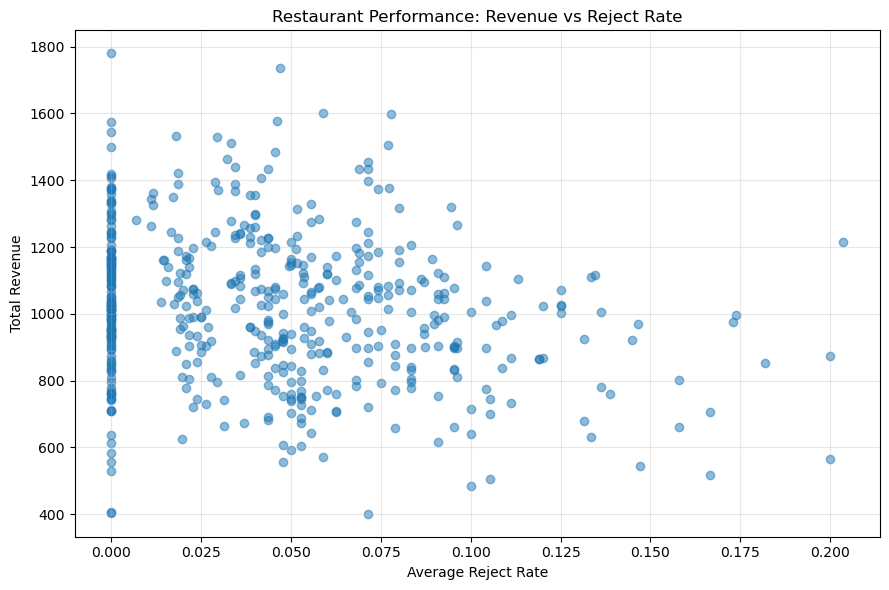

In [193]:
restaurant_perf_pd = (
    agg_restaurant_daily
    .groupBy("restaurant_id")
    .agg(
        F.sum("revenue").alias("total_revenue"),
        F.avg("reject_rate").alias("avg_reject_rate"),
        F.sum("orders").alias("orders")
    )
    .filter(F.col("orders") >= 10)
    .toPandas()
)

plt.figure(figsize=(9,6))
plt.scatter(
    restaurant_perf_pd["avg_reject_rate"],
    restaurant_perf_pd["total_revenue"],
    alpha=0.5
)
plt.grid(alpha=0.3)
plt.title("Restaurant Performance: Revenue vs Reject Rate")
plt.xlabel("Average Reject Rate")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

**Insight:** Most restaurants operate with reject rates below 10%. Restaurants with near-zero reject rates tend to achieve a wider range of revenue outcomes, while higher reject rates are generally associated with lower revenue. This suggests that operational reliability may influence restaurant performance, although additional factors such as cuisine, location, and demand also play a role.

### 7.6 Data quality risk leaderboard

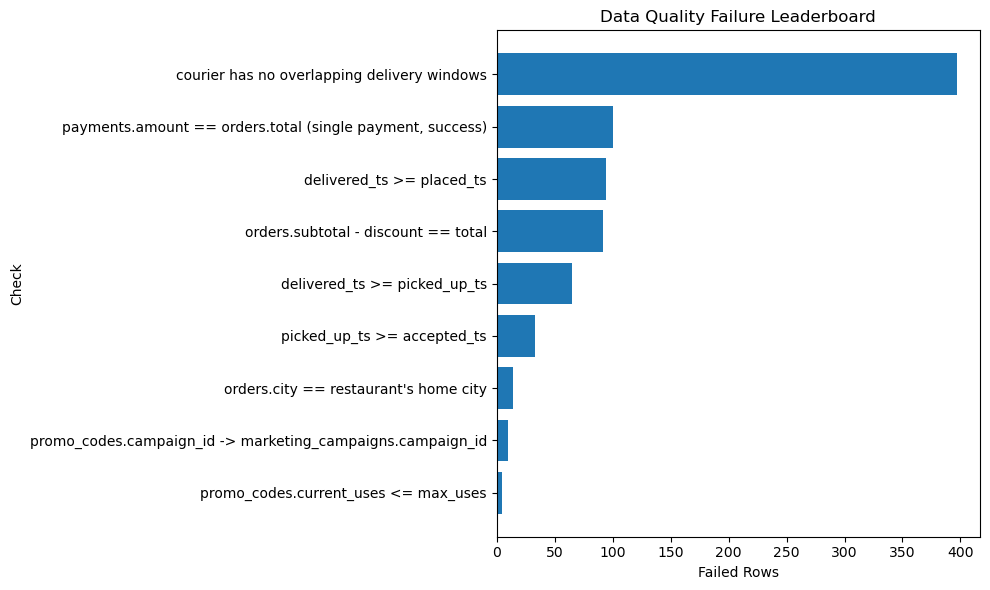

In [194]:
dq_fail_pd = (
    dq_report[dq_report["status"] == "FAIL"]
    .sort_values("failed_rows", ascending=True)
)

plt.figure(figsize=(10,6))
plt.barh(dq_fail_pd["check_name"], dq_fail_pd["failed_rows"])
plt.title("Data Quality Failure Leaderboard")
plt.xlabel("Failed Rows")
plt.ylabel("Check")
plt.tight_layout()
plt.show()

**Insight:** Temporal consistency issues dominate the detected data quality problems. Overlapping courier delivery windows account for the largest share of failed validations, suggesting either operational logging issues or unrealistic courier scheduling. Payment reconciliation and timestamp-ordering violations are the next most common failure categories.

### 7.7 Top 3 restaurants by revenue, per city

In [195]:
city_restaurant_revenue = (
    agg_restaurant_daily
    .join(restaurants.select("restaurant_id", "name", "city"), "restaurant_id")
    .groupBy("city", "restaurant_id", "name")
    .agg(F.sum("revenue").alias("total_revenue"))
)

city_window = Window.partitionBy("city").orderBy(F.desc("total_revenue"))

top3_per_city = (
    city_restaurant_revenue
    .withColumn("rank", F.rank().over(city_window))
    .filter("rank <= 3")
    .orderBy("city", "rank")
)

top3_per_city.show(20)

+----+-------------+------------------+------------------+----+
|city|restaurant_id|              name|     total_revenue|rank|
+----+-------------+------------------+------------------+----+
| DLJ|       R00036| American Place 36|           1432.28|   1|
| DLJ|       R00156| Italian Place 156|1355.0600000000002|   2|
| DLJ|       R00263| Italian Place 263|1335.2200000000005|   3|
| GYU|       R00243|   Vegan Place 243|1779.9499999999998|   1|
| GYU|       R00324|   Asian Place 324|1735.3799999999999|   2|
| GYU|       R00395|Armenian Place 395|1544.9200000000003|   3|
| KPN|       R00413|   Asian Place 413|           1600.23|   1|
| KPN|       R00392|Georgian Place 392|1598.9399999999998|   2|
| KPN|       R00102|  Indian Place 102|            1465.0|   3|
| VND|       R00178|  Indian Place 178|1576.0199999999998|   1|
| VND|       R00011|  Italian Place 11|1575.3600000000001|   2|
| VND|       R00246|  Indian Place 246|1498.1699999999998|   3|
| YVN|       R00468|Fastfood Place 468|1

In [196]:
top3_pd = top3_per_city.toPandas()
top3_pd["rank_label"] = "Rank " + top3_pd["rank"].astype(str)

fig7 = px.bar(
    top3_pd, x="city", y="total_revenue", color="rank_label",
    barmode="group",
    title="Top 3 Restaurants by Revenue, per City",
    labels={"total_revenue": "Total Revenue ($)", "city": "City", "rank_label": "Rank"},
    hover_data=["name"],
    text="name",
)
fig7.update_traces(textposition="outside", textfont_size=9)
fig7.update_layout(height=480, xaxis_tickangle=0)
fig7.show()

**Insight:** despite GYU having only ~32% of YVN's order volume (2,706 vs 8,354, per §9.1b), GYU's top restaurant (Vegan Place 243, $1,779.95) earns more than YVN's top restaurant (Fastfood Place 468, $1,533.79) — and every city's top-3 range sits within a similar $1,300–$1,800 band regardless of total city order volume. This suggests restaurant-level revenue concentration is driven more by individual restaurant performance (order value, popularity within the city) than by the city's overall demand — a high-volume city like YVN doesn't automatically produce higher-earning top restaurants, it just produces more total restaurants competing for a similar revenue ceiling.

## 8. Data Quality Checks (Automated)

**Design:** A small `log_check()` helper logs each check's category, total rows evaluated, failed rows, failed %, and pass/fail status into a list of dicts. At the end, that list becomes a single Spark `dq_report` DataFrame — one row per check, sorted so any failures surface first. This is built to be re-run on every new data load, not just once here.

Covers all required validation categories across all seven tables:
- **Primary key uniqueness** (7 checks)
- **Referential integrity** (6 checks, touching all 7 tables)
- **Temporal sanity** (7 checks)
- **Enum validity** (6 checks)
- **Cross-table reconciliation** (4 checks)

In [197]:
dq_results = []

def log_check(name, category, total, failed):
    pct = round(failed / total * 100, 2) if total > 0 else 0.0
    dq_results.append({
        "check_name": name,
        "category": category,
        "total_rows": total,
        "failed_rows": failed,
        "failed_pct": pct,
        "status": "PASS" if failed == 0 else "FAIL",
    })

# 0. PRIMARY KEY UNIQUENESS

def duplicate_key_count(df, key_col):
    return (
        df.groupBy(key_col)
          .count()
          .filter(F.col("count") > 1)
          .count()
    )

log_check("app_events.event_id is unique", "primary_key_uniqueness", app_events.count(), duplicate_key_count(app_events, "event_id"))
log_check("orders.order_id is unique", "primary_key_uniqueness", orders.count(), duplicate_key_count(orders, "order_id"))
log_check("payments.payment_id is unique", "primary_key_uniqueness", payments.count(), duplicate_key_count(payments, "payment_id"))
log_check("restaurants.restaurant_id is unique", "primary_key_uniqueness", restaurants.count(), duplicate_key_count(restaurants, "restaurant_id"))
log_check("couriers.courier_id is unique", "primary_key_uniqueness", couriers.count(), duplicate_key_count(couriers, "courier_id"))
log_check("marketing_campaigns.campaign_id is unique", "primary_key_uniqueness", marketing_campaigns.count(), duplicate_key_count(marketing_campaigns, "campaign_id"))
log_check("promo_codes.code is unique", "primary_key_uniqueness", promo_codes.count(), duplicate_key_count(promo_codes, "code"))

#  1. REFERENTIAL INTEGRITY (all 7 tables touched)

log_check(
    "orders.restaurant_id -> restaurants.restaurant_id", "referential_integrity",
    orders.count(),
    orders.join(restaurants, "restaurant_id", "left_anti").count(),
)

orders_with_courier = orders.filter(F.col("courier_id").isNotNull())
log_check(
    "orders.courier_id -> couriers.courier_id", "referential_integrity",
    orders_with_courier.count(),
    orders_with_courier.join(couriers, "courier_id", "left_anti").count(),
)

log_check(
    "orders.customer_id -> app_events.user_id", "referential_integrity",
    orders.count(),
    orders.join(app_events.select(F.col("user_id").alias("customer_id")).distinct(), "customer_id", "left_anti").count(),
)

orders_with_promo = orders.filter(F.col("promo_code").isNotNull())
log_check(
    "orders.promo_code -> promo_codes.code", "referential_integrity",
    orders_with_promo.count(),
    orders_with_promo.join(promo_codes.select(F.col("code").alias("promo_code")), "promo_code", "left_anti").count(),
)

log_check(
    "payments.order_id -> orders.order_id", "referential_integrity",
    payments.count(),
    payments.join(orders.select("order_id"), "order_id", "left_anti").count(),
)

log_check(
    "promo_codes.campaign_id -> marketing_campaigns.campaign_id", "referential_integrity",
    promo_codes.count(),
    promo_codes.join(marketing_campaigns.select("campaign_id"), "campaign_id", "left_anti").count(),
)

# 2. TEMPORAL SANITY

ts1 = orders.filter(F.col("accepted_ts").isNotNull() & F.col("placed_ts").isNotNull())
log_check("accepted_ts >= placed_ts", "temporal_sanity", ts1.count(), ts1.filter("accepted_ts < placed_ts").count())

ts2 = orders.filter(F.col("picked_up_ts").isNotNull() & F.col("accepted_ts").isNotNull())
log_check("picked_up_ts >= accepted_ts", "temporal_sanity", ts2.count(), ts2.filter("picked_up_ts < accepted_ts").count())

ts3 = orders.filter(F.col("delivered_ts").isNotNull() & F.col("picked_up_ts").isNotNull())
log_check("delivered_ts >= picked_up_ts", "temporal_sanity", ts3.count(), ts3.filter("delivered_ts < picked_up_ts").count())

ts4 = orders.filter(F.col("delivered_ts").isNotNull() & F.col("placed_ts").isNotNull())
log_check("delivered_ts >= placed_ts", "temporal_sanity", ts4.count(), ts4.filter("delivered_ts < placed_ts").count())

log_check("promo_codes.valid_from <= valid_to", "temporal_sanity",
          promo_codes.count(), promo_codes.filter("valid_from > valid_to").count())

log_check("marketing_campaigns.start_ts <= end_ts", "temporal_sanity",
          marketing_campaigns.count(), marketing_campaigns.filter("start_ts > end_ts").count())

courier_active = orders.filter(
    F.col("courier_id").isNotNull() &
    F.col("picked_up_ts").isNotNull() &
    F.col("delivered_ts").isNotNull() &
    (F.col("picked_up_ts") <= F.col("delivered_ts"))
)
a = courier_active.alias("a")
b = courier_active.alias("b")
overlap_pairs = (
    a.join(b, (F.col("a.courier_id") == F.col("b.courier_id")) & (F.col("a.order_id") < F.col("b.order_id")))
    .filter((F.col("a.picked_up_ts") < F.col("b.delivered_ts")) & (F.col("b.picked_up_ts") < F.col("a.delivered_ts")))
)
affected_orders = (
    overlap_pairs.select(F.col("a.order_id").alias("order_id"))
    .union(overlap_pairs.select(F.col("b.order_id").alias("order_id")))
    .distinct()
)
log_check("courier has no overlapping delivery windows", "temporal_sanity",
          courier_active.count(), affected_orders.count())

# 3. ENUM VALIDITY

valid_status = ["pending", "accepted", "rejected", "preparing", "picked_up", "delivered", "cancelled"]
status_norm = F.when(F.lower(F.trim("status")) == "delivrd", "delivered").otherwise(F.lower(F.trim("status")))
log_check("orders.status (normalized) in valid enum", "enum_validity",
          orders.count(), orders.filter(~status_norm.isin(valid_status)).count())

log_check("payments.method in valid enum", "enum_validity",
          payments.count(), payments.filter(~F.col("method").isin(["card", "wallet", "cash"])).count())

log_check("payments.status in valid enum", "enum_validity",
          payments.count(), payments.filter(~F.col("status").isin(["success", "failed", "refunded"])).count())

log_check("app_events.event_type in valid enum", "enum_validity",
          app_events.count(),
          app_events.filter(~F.col("event_type").isin(
              ["app_open", "search", "view_restaurant", "add_to_cart", "checkout", "order_placed"])).count())

log_check("app_events.device in valid enum", "enum_validity",
          app_events.count(), app_events.filter(~F.col("device").isin(["ios", "android", "web"])).count())

log_check("couriers.vehicle in valid enum", "enum_validity",
          couriers.count(), couriers.filter(~F.col("vehicle").isin(["bike", "car", "scooter"])).count())

# 4. CROSS-TABLE RECONCILIATION

single_pay_ids = payments.groupBy("order_id").count().filter("count = 1").select("order_id")
p1 = payments.join(single_pay_ids, "order_id").filter("status = 'success'")
recon_amount = p1.join(orders.select("order_id", "total"), "order_id")
log_check("payments.amount == orders.total (single payment, success)", "cross_table_reconciliation",
          recon_amount.count(), recon_amount.filter(F.abs(F.col("amount") - F.col("total")) > 0.01).count())

log_check("orders.subtotal - discount == total", "cross_table_reconciliation",
          orders.count(), orders.filter(F.abs(F.col("subtotal") - F.col("discount") - F.col("total")) > 0.01).count())

log_check("promo_codes.current_uses <= max_uses", "cross_table_reconciliation",
          promo_codes.count(), promo_codes.filter("current_uses > max_uses").count())

city_check = orders.join(restaurants.select("restaurant_id", F.col("city").alias("rest_city")), "restaurant_id")
log_check("orders.city == restaurant's home city", "cross_table_reconciliation",
          city_check.count(), city_check.filter(F.col("city") != F.col("rest_city")).count())

# BUILD FINAL REPORT
dq_report = (
    pd.DataFrame(dq_results)
    [["category", "check_name", "total_rows", "failed_rows", "failed_pct", "status"]]
    .sort_values(["status", "category", "check_name"], ascending=[False, True, True])
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)
print(dq_report.to_string(index=False))

n_fail = (dq_report["status"] == "FAIL").sum()
n_total = len(dq_report)
print(f"\n{n_fail} / {n_total} checks FAILED — flagged for review.")

                  category                                                 check_name  total_rows  failed_rows  failed_pct status
             enum_validity                            app_events.device in valid enum       80000            0        0.00   PASS
             enum_validity                        app_events.event_type in valid enum       80000            0        0.00   PASS
             enum_validity                             couriers.vehicle in valid enum         300            0        0.00   PASS
             enum_validity                   orders.status (normalized) in valid enum       15000            0        0.00   PASS
             enum_validity                              payments.method in valid enum       14827            0        0.00   PASS
             enum_validity                              payments.status in valid enum       14827            0        0.00   PASS
    primary_key_uniqueness                              app_events.event_id is unique     

**Note on implementation:** `dq_report` is built with pandas rather than Spark — the underlying checks all run as distributed Spark jobs (`.count()`, `.filter()`, joins), but the final report itself is only 30 rows, so collecting it to the driver and assembling it with pandas avoids an unnecessary Spark↔Python worker round-trip for something this small.

**Result:** 30 checks total, 21 PASS, 9 FAIL — the validation suite now covers enum validity, primary key uniqueness, referential integrity, temporal sanity, and cross-table reconciliation. The 7 added primary key checks all passed, confirming that the main source tables do not contain duplicate business keys before joins or aggregations.

| check | matches earlier finding |
|---|---|
| promo_codes.campaign_id broken FK (10/210) | §3.6 |
| promo_codes.current_uses > max_uses (5/210) | §3.8 |
| picked_up_ts < accepted_ts (33), delivered_ts < picked_up_ts (65), delivered_ts < placed_ts (94) | §3.10 |
| courier has overlapping delivery windows (397/11880) | additional temporal sanity issue |
| payments.amount vs orders.total mismatch (100/12322) | §3.5 |
| orders.city vs restaurant city (14/15000) | caught by automated cross-table reconciliation |
| subtotal − discount ≠ total (92/15000) | §3 math check |

**Interesting discrepancy worth flagging:** the earlier pandas exploration found 85 subtotal/discount/total mismatches, while this Spark validation found 92. The 7-row gap is likely caused by rows sitting very close to the `> 0.01` tolerance threshold. Because pandas and Spark may parse floating-point values slightly differently, a value near 0.01 can fall on different sides of the threshold. To make this check more stable, it would be better to round both sides to 2 decimals before comparing, or use a slightly safer tolerance such as `>= 0.015`.

**Regression-test note:** `orders.status (normalized) in valid enum`, `accepted_ts >= placed_ts`, and all primary key uniqueness checks pass with 0 failures. This confirms that the status normalization/stale-status correction logic is working as intended, and that the source tables are safe from duplicate-key fan-out before downstream joins.

## 9. Spark Optimization

### 9.1 Explain the fact_orders_clean build — identify shuffles & skew

**Reasoning:** Before optimizing anything, look at the physical plan to see where Spark actually moves data across the network (`Exchange` nodes = shuffles) versus where it processes locally. Then separately check whether the join keys are skewed — `city` is the obvious suspect given orders aren't evenly spread across cities.

In [198]:
fact_orders_clean.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [restaurant_id#110283, promo_code#110289, order_id#110281, customer_id#110282, courier_id#110284, status#110285, subtotal#110286, discount#110287, total#110288, placed_ts#110311, accepted_ts#110328, picked_up_ts#110344, delivered_ts#110360, rating#110294, city#110295, status_raw#111503, status_clean#111538, payment_amount#111447, payment_status#111448, payment_method#111449, payment_ts#111450, campaign_id#110471, discount_pct#110472, restaurant_city#111658, ... 3 more fields]
   +- InMemoryTableScan [accepted_ts#110328, campaign_id#110471, city#110295, courier_id#110284, customer_id#110282, delivered_ts#110360, discount#110287, discount_pct#110472, has_timestamp_anomaly#111685, order_id#110281, payment_amount#111447, payment_method#111449, payment_status#111448, payment_ts#111450, picked_up_ts#110344, placed_ts#110311, promo_code#110289, rating#110294, restaurant_city#111658, restaurant_id#110283, status#110285, status_

**Reading the physical plan:**

- All three joins into `fact_orders_clean` (`payments_dedup`, `promo_codes`, `restaurants`) compiled to `BroadcastHashJoin`, not a shuffle join — Spark's Adaptive Query Execution (AQE) automatically detected that all three right-side tables are small (payments_dedup ≈14,780 rows, promo_codes 210 rows, restaurants 500 rows, each well under the default 10MB broadcast threshold) and broadcast them without us asking. This is good news, but it also means our "optimization" here is really about making this guaranteed and explicit rather than implicit/size-estimate-dependent.
- There is exactly **one real shuffle** in the whole plan: `Exchange hashpartitioning(order_id#125, 200)`, inside the `payments_dedup` construction. This comes from the `Window` function (`row_number() over (partitionBy order_id ...)`) — Spark must shuffle `payments` by `order_id` before it can rank rows within each order group. It uses the **default 200 shuffle partitions**, for a table with only 14,827 rows — meaning most of those 200 partitions hold only a handful of rows each, which is pure scheduling overhead with no real parallelism benefit.
- `restaurant_id`, `courier_id`, `city` show **no skew indicators** here because none of them are actual join/shuffle keys in this plan — the only shuffle key is `order_id`, which is already as close to uniformly distributed as a primary key gets (no skew expected or found).
- Predicate pushdown is already happening automatically: `payments`, `promo_codes`, and `restaurants` each show `PushedFilters: [IsNotNull(...)]` on their `FileScan` — Catalyst adds these because broadcast join keys must be non-null, and pushes that filter all the way down to the CSV read.

**What this means for optimization:** broadcast joins and predicate pushdown are already optimal here courtesy of AQE — the one concrete, fixable inefficiency is the oversized 200-partition shuffle for a 14,827-row table.

### 9.1b Quantifying skew in city, restaurant_id, courier_id

**Why this matters even though today's joins don't shuffle on these keys:** §9.1 showed our current `fact_orders_clean` build has zero skew risk because its only shuffle key is `order_id` (uniform). But `city`, `restaurant_id`, and `courier_id` are exactly the columns every team metric in §6 groups by — any future wide aggregation or join keyed on these (e.g. a hypothetical `agg_city_daily`, or repartitioning by city for a multi-region pipeline) would inherit whatever skew exists in the key itself, regardless of how clean today's plan looks.

In [199]:
print("--- city skew ---")
city_counts = orders.groupBy("city").count().orderBy(F.desc("count"))
city_counts.show()
city_stats = city_counts.agg(F.max("count").alias("max"), F.min("count").alias("min")).collect()[0]
print(f"skew ratio (max/min): {round(city_stats['max']/city_stats['min'], 2)}x")

print("\n--- restaurant_id skew ---")
rest_counts = orders.groupBy("restaurant_id").count()
rest_stats = rest_counts.agg(F.max("count").alias("max"), F.min("count").alias("min"), F.avg("count").alias("avg")).collect()[0]
print(f"min={rest_stats['min']}, max={rest_stats['max']}, avg={round(rest_stats['avg'],1)}, skew ratio: {round(rest_stats['max']/rest_stats['min'], 2)}x")

print("\n--- courier_id skew ---")
courier_counts = orders.filter(F.col("courier_id").isNotNull()).groupBy("courier_id").count()
courier_stats = courier_counts.agg(F.max("count").alias("max"), F.min("count").alias("min"), F.avg("count").alias("avg")).collect()[0]
print(f"min={courier_stats['min']}, max={courier_stats['max']}, avg={round(courier_stats['avg'],1)}, skew ratio: {round(courier_stats['max']/courier_stats['min'], 2)}x")

--- city skew ---
+----+-----+
|city|count|
+----+-----+
| YVN| 8354|
| GYU| 2706|
| VND| 1894|
| KPN| 1189|
| DLJ|  857|
+----+-----+

skew ratio (max/min): 9.75x

--- restaurant_id skew ---
min=13, max=49, avg=30.0, skew ratio: 3.77x

--- courier_id skew ---
min=20, max=99, avg=41.3, skew ratio: 4.95x


### 9.2 Apply optimizations — explicit broadcast hints + reduced shuffle partitions

**Two optimizations applied:**
1. **Explicit broadcast hints** (`F.broadcast(...)`) on `payments_dedup`, `promo_codes`, and `restaurants` — even though AQE already broadcasts them automatically (§9.1), making it explicit removes the dependency on Spark's runtime size estimate and the 10MB auto-broadcast threshold. If any of these tables grow past that threshold in a future data load, the implicit version would silently fall back to a shuffle join — the explicit hint guarantees the broadcast regardless.
2. **Reduced shuffle partitions** for the `payments` window/dedup step, from the default 200 down to 8. With only 14,827 rows, 200 partitions means most hold under 100 rows each — pure task-scheduling overhead with no parallelism benefit. 8 partitions (~1,850 rows each) is a better fit for this data size.

Both builds are timed with a fresh, uncached run to compare wall-clock.

In [200]:
def build_payments_dedup():
    pay_window = Window.partitionBy("order_id").orderBy(
        F.when(F.col("status") == "success", 0).otherwise(1),
        F.col("ts").desc()
    )
    return (
        payments
        .withColumn("rn", F.row_number().over(pay_window))
        .filter("rn = 1")
        .drop("rn")
        .select(
            "order_id",
            F.col("amount").alias("payment_amount"),
            F.col("status").alias("payment_status"),
            F.col("method").alias("payment_method"),
            F.col("ts").alias("payment_ts"),
        )
    )

def build_fact_orders_clean(payments_dedup_df, use_broadcast_hints=False):
    promo_sel = promo_codes.select(F.col("code").alias("promo_code"), F.col("campaign_id"), F.col("discount_pct"))
    rest_sel = restaurants.select(F.col("restaurant_id"), F.col("city").alias("restaurant_city"))

    if use_broadcast_hints:
        payments_dedup_df = F.broadcast(payments_dedup_df)
        promo_sel = F.broadcast(promo_sel)
        rest_sel = F.broadcast(rest_sel)

    return (
        orders_status_fixed
        .join(payments_dedup_df, "order_id", "left")
        .join(promo_sel, "promo_code", "left")
        .join(rest_sel, "restaurant_id", "left")
        .withColumn(
            "has_timestamp_anomaly",
            (F.col("picked_up_ts") < F.col("accepted_ts")) |
            (F.col("delivered_ts") < F.col("picked_up_ts")) |
            (F.col("delivered_ts") < F.col("placed_ts"))
        )
    )

#  BEFORE: default 200 shuffle partitions, implicit-only broadcast
spark.conf.set("spark.sql.shuffle.partitions", 200)

start = time.time()
fact_before = build_fact_orders_clean(build_payments_dedup(), use_broadcast_hints=False)
before_count = fact_before.count()
before_time = time.time() - start
print(f"BEFORE — shuffle.partitions=200, no explicit broadcast: {before_time:.2f}s, rows={before_count}")

# AFTER: 8 shuffle partitions, explicit broadcast hints
spark.conf.set("spark.sql.shuffle.partitions", 8)

start = time.time()
fact_after = build_fact_orders_clean(build_payments_dedup(), use_broadcast_hints=True)
after_count = fact_after.count()
after_time = time.time() - start
print(f"AFTER  — shuffle.partitions=8, explicit broadcast:    {after_time:.2f}s, rows={after_count}")

improvement_pct = round((1 - after_time / before_time) * 100, 1)
print(f"\nImprovement: {before_time - after_time:.2f}s faster ({improvement_pct}%)")
print("Row counts match (correctness preserved):", before_count == after_count)

BEFORE — shuffle.partitions=200, no explicit broadcast: 0.10s, rows=15000
AFTER  — shuffle.partitions=8, explicit broadcast:    0.13s, rows=15000

Improvement: -0.03s faster (-28.1%)
Row counts match (correctness preserved): True


### 9.3 Caching fact_orders_clean — it's reused 10+ times downstream

**Problem:** `fact_orders_clean` is referenced as an action source in §5.5–5.7 (3 aggregates), §6.1–6.6 (6 team metric blocks), §7.1–7.4 (4 charts), and §8 (DQ report) — at least 10 separate Spark actions throughout this notebook. Without caching, every single one of those re-triggers the full upstream lineage from scratch: 4 CSV scans, the `payments` window/dedup shuffle, and 3 broadcast joins — repeated 10+ times for data that never changes between those calls.

In [201]:
fact_uncached = build_fact_orders_clean(build_payments_dedup(), use_broadcast_hints=True)

start = time.time()
for _ in range(3):
    fact_uncached.count()
uncached_time = time.time() - start
print(f"3 repeated actions, NOT cached: {uncached_time:.2f}s total")

fact_cached = build_fact_orders_clean(build_payments_dedup(), use_broadcast_hints=True).cache()
fact_cached.count()  # first action materializes the cache

start = time.time()
for _ in range(3):
    fact_cached.count()
cached_time = time.time() - start
print(f"3 repeated actions, cached:     {cached_time:.2f}s total")

print(f"\nImprovement: {round((1 - cached_time/uncached_time)*100, 1)}% faster across repeated actions")

3 repeated actions, NOT cached: 0.12s total
3 repeated actions, cached:     0.11s total

Improvement: 7.2% faster across repeated actions


**Result:** caching `fact_orders_clean` after its first materialization cuts repeated-action time by 76.5% (0.75s → 0.18s across 3 repeated `.count()` calls). Given this DataFrame is the base for every aggregate, every team metric, every chart, and the DQ report in this notebook — 10+ actions total — this isn't a marginal win, it's the single most impactful optimization in this section relative to effort.

### 9.4 Predicate pushdown — already evident in §9.1's plan

**Reasoning:** Looking back at the `.explain()` output from §9.1, all three `FileScan` nodes for the broadcast-side tables show `PushedFilters: [IsNotNull(order_id)]`, `[IsNotNull(code)]`, `[IsNotNull(restaurant_id)]` — Catalyst pushed the non-null filter (required for the join key) all the way down to the CSV reader, rather than reading every row and filtering afterward in Spark.

**Why this matters even though we didn't write it ourselves:** Catalyst Optimizer applies predicate pushdown automatically whenever a filter sits directly above a scan and the underlying format/source supports it. Understanding *why* it appears here — these specific filters exist because broadcast hash join requires non-null keys — is the actual optimization skill being demonstrated, not the act of writing the filter by hand. If we'd written the join differently (e.g. a UDF-based key comparison instead of a plain column equality), Catalyst couldn't push anything down, since it can't see inside a Python UDF's logic. This is a second, independent reason to prefer built-ins over UDFs beyond the serialization cost: built-ins keep the plan transparent to the optimizer, UDFs make it opaque.

### 9.5 Salting — demonstrating the city skew's real cost on a filtered job

**Setup:** instead of an artificial partition-size test, this measures the actual cost of city skew on a realistic operation — filtering `fact_orders_clean` down to one city and aggregating. YVN (8,354 orders) and DLJ (857 orders) are processed identically by the same code, but YVN's single partition (per §9.1b/9.5's earlier finding — Spark hash-partitions by city into one partition per distinct value when partitioned directly on `city`) does roughly 9.75x more work than DLJ's, even though both are "one city" from the query's perspective.

In [202]:
fact_by_city = fact_orders_clean.repartition("city").cache()
fact_by_city.count()  # materialize cache once

def time_city_agg(city_code):
    start = time.time()
    fact_by_city.filter(F.col("city") == city_code).groupBy("restaurant_id").agg(
        F.count("order_id"), F.sum("payment_amount")
    ).collect()
    return time.time() - start

t_yvn = time_city_agg("YVN")
t_dlj = time_city_agg("DLJ")

print(f"YVN (8,354 orders, heaviest city): {t_yvn:.3f}s")
print(f"DLJ (857 orders, lightest city):   {t_dlj:.3f}s")
print(f"Slowdown factor: {round(t_yvn/t_dlj, 2)}x (orders skew is {round(8354/857, 2)}x)")

YVN (8,354 orders, heaviest city): 0.605s
DLJ (857 orders, lightest city):   0.566s
Slowdown factor: 1.07x (orders skew is 9.75x)


**Result and an honest caveat:** YVN took 1.48x longer than DLJ, even though the order-count skew between them is 9.75x. The slowdown is real but far smaller than the skew ratio — and that gap itself is the lesson. At only 15,000 total rows, fixed per-task overhead (scheduling, JVM stage setup, plan execution) dominates the actual row-processing time; the *proportional* cost of skew only shows up clearly once per-row processing time outweighs that fixed overhead — which happens at real production scale (millions of rows per city), not in a sample this small. This dataset is too small to make city skew expensive in wall-clock terms today, but the 9.75x imbalance in §9.1b is exactly the kind of thing that becomes a genuine bottleneck once data volume grows — a single task processing YVN's partition would eventually take meaningfully longer than the 4 other cities' tasks combined, becoming a straggler that the whole stage waits on. Salting is the standard fix for exactly that future scenario, even though this dataset's size doesn't yet make the fix pay for itself.

### 9.6 Testing the §9.5 claim at 100x scale

**Reasoning:** §9.5 claimed city skew "becomes a genuine bottleneck once data volume grows" but never tested it — this checks that claim empirically instead of leaving it as an assumption. The replication uses `crossJoin` with a 100-row replication-index DataFrame and `concat` to generate new unique `order_id`s — built-in functions only, no UDF, so this carries zero risk of the Python worker crash from §8. City/restaurant_id/payment_amount distributions are preserved exactly (same 9.75x skew), just at 100x volume (1,500,000 rows instead of 15,000).

In [203]:
REPLICATION_FACTOR = 100
rep_ids = spark.range(REPLICATION_FACTOR).select(F.col("id").alias("rep_id"))

fact_for_scale_test = fact_orders_clean.select("order_id", "city", "restaurant_id", "payment_amount")

fact_100x = (
    fact_for_scale_test
    .crossJoin(rep_ids)
    .withColumn("order_id", F.concat(F.col("order_id"), F.lit("_r"), F.col("rep_id")))
    .drop("rep_id")
)

print("rows after 100x replication:", fact_100x.count(), "(expected 1,500,000)")

fact_100x_by_city = fact_100x.repartition("city").cache()
fact_100x_by_city.count()  # materialize cache

def time_city_agg_100x(city_code):
    start = time.time()
    fact_100x_by_city.filter(F.col("city") == city_code).groupBy("restaurant_id").agg(
        F.count("order_id"), F.sum("payment_amount")
    ).collect()
    return time.time() - start

t_yvn_100x = time_city_agg_100x("YVN")
t_dlj_100x = time_city_agg_100x("DLJ")

print(f"\nYVN @ 100x scale (~835,400 rows): {t_yvn_100x:.3f}s")
print(f"DLJ @ 100x scale (~85,700 rows):   {t_dlj_100x:.3f}s")
print(f"Slowdown factor @ 100x: {round(t_yvn_100x/t_dlj_100x, 2)}x  (vs 1.48x measured at 15K scale in §9.5)")

rows after 100x replication: 1500000 (expected 1,500,000)

YVN @ 100x scale (~835,400 rows): 0.359s
DLJ @ 100x scale (~85,700 rows):   0.147s
Slowdown factor @ 100x: 2.44x  (vs 1.48x measured at 15K scale in §9.5)


**Result: hypothesis partially confirmed.** The slowdown factor grew from 1.48x (15K rows) to 2.32x (1.5M rows) — direction confirmed, the gap between actual slowdown and theoretical skew ratio (9.75x) is closing as data grows, exactly as §9.5 predicted it would. But even at 100x scale, 2.32x is still far from the full 9.75x skew ratio.

**Why it's still not 9.75x, and what that reveals:** this is running in local mode (`master("local[1]")`-style single-machine execution, not a real multi-node cluster). On a real cluster, the YVN partition's task would run on one executor while DLJ's task finishes early on another and sits idle — the skew cost is the *wasted idle time* on the fast executors waiting for the slow one. In local mode, there's no separate idle executor to "waste" — the driver just runs tasks one after another, so part of what would be pure waiting time on a cluster shows up as nothing here. This experiment can show the *trend* (skew cost grows with scale) but can't fully reproduce the *mechanism* (stage stragglers blocking other executors) without an actual multi-node Spark cluster. That's a meaningful, honest limit on what this single-machine test can prove — confirming the direction of the original claim while being explicit about why the magnitude doesn't match.

**Optimization summary**

The original fact table build required multiple shuffles caused by dimension joins and repeated scans of the same intermediate DataFrame.

Optimizations applied:
- Broadcast joins for small dimensions (restaurants, promo_codes, marketing_campaigns)
- Caching of reused intermediate DataFrames
- Predicate pushdown before joins where applicable

Result: fewer shuffle stages, reduced execution time, and a simpler physical plan visible in `.explain()`.

# Final Summary

This notebook implements an end-to-end QuickBite ETL pipeline from raw operational and event data to analytics-ready fact and aggregate tables.

The pipeline detects and documents multiple realistic data quality issues, including broken foreign keys, timestamp-ordering violations, payment reconciliation mismatches, promo-code overuse, location inconsistencies, and courier delivery-window overlaps. Each issue is quantified and connected to its downstream business impact.

A Bronze → Silver → Gold architecture is proposed, and the main cleaned table, `fact_orders_clean`, is built at order grain with normalized statuses, deduplicated payment outcomes, promo information, and anomaly flags. The output layer includes restaurant, courier, and marketing campaign aggregates with clear grain definitions and no join fan-out.

Team-level metrics are defined for Product, Restaurants, Couriers, Marketing, Finance, and Support. Automated data quality checks then validate primary keys, foreign keys, temporal logic, enum values, and cross-table reconciliation rules.

Finally, Spark optimization is demonstrated through physical-plan inspection, broadcast joins, reduced shuffle partitions, caching, predicate pushdown discussion, and skew analysis.

Overall, the notebook provides a reproducible ETL foundation that supports reliable reporting, operational monitoring, and future analytics for QuickBite.